<h1 align="center"> PROGETTO DATA MINING 2024/2025</h1>  <i><p align="right" style="font-size:24px;">Ilaria Lanciotto 245973</p></i>

<center><h3 style = "background:#98c1d9 ;color:black;border:0;font-weight:bold">Lettura da input</h3></center>

In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_predict
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import  f1_score, recall_score, precision_score
from sklearn.model_selection import StratifiedKFold
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

df = pd.read_csv("data.csv", sep=",")  
result = {} 
print(df.isnull().sum())
print("duplicati: ",df.duplicated().sum())
df.head()

asm_commands_add     0
asm_commands_call    0
asm_commands_cdq     0
asm_commands_cld     0
asm_commands_cli     0
                    ..
asm_commands_xchg    0
asm_commands_xor     0
line_count_asm       0
size_asm             0
Class                0
Length: 69, dtype: int64
duplicati:  80


,asm_commands_add,asm_commands_call,asm_commands_cdq,asm_commands_cld,asm_commands_cli,asm_commands_cmc,asm_commands_cmp,asm_commands_cwd,asm_commands_daa,asm_commands_dd,...,asm_commands_sti,asm_commands_stos,asm_commands_sub,asm_commands_test,asm_commands_wait,asm_commands_xchg,asm_commands_xor,line_count_asm,size_asm,Class
0,436,646.0,0.0,10.0,9.0,0.0,228.0,0.0,56.0,89930,...,1.0,0.0,892.0,53.0,10.0,0.0,162.0,118529,6874624,2
1,469,262.0,0.0,4.0,1.0,4.0,185.0,4.0,20.0,3464,...,3.0,7.0,846.0,8.0,0.0,9.0,19.0,7937,460288,8
2,1587,1828.0,0.0,0.0,31.0,0.0,689.0,0.0,904.0,24833,...,1.0,0.0,4005.0,680.0,44.0,0.0,418.0,90625,5256192,9
3,213,227.0,0.0,0.0,3.0,0.0,127.0,0.0,132.0,71979,...,0.0,0.0,437.0,78.0,0.0,0.0,199.0,83201,4825600,9
4,36,76.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,112,...,2.0,3.0,82.0,16.0,0.0,0.0,18.0,12289,712704,1


<i> In questo progetto è stato analizzato un dataset di eseguibili per rilevare comportamenti sospetti.Questo set di dati è una versione pulita dei dati della competizione Microsoft Malware Classification Challenge (BIG 2015). Poiché nei dati originali abbiamo file binari e asm, è stato creato creato un set di dati codificato a caldo da esso. è possibile infatti vedere che ongi atttibuto è numerico e non sono presenti null , ma sono prsenti dei duplicati. A questo punto per rendere i dati piu puliti possiamo eliminare i duplicati in quando ridondanti</i>

In [53]:
df.drop_duplicates(inplace=True)

<center><h3 style = "background:#98c1d9 ;color:black;border:0;font-weight:bold">Data Exploration</h3></center>


 Attributi con correlazione > 0.8 con 'asm_commands_call':
asm_commands_push    0.964490
asm_commands_lea     0.946829
asm_commands_or      0.939482
asm_commands_jz      0.936707
asm_commands_endp    0.936329
asm_commands_ret     0.929851
asm_commands_pop     0.916216
asm_commands_test    0.906960
asm_commands_cmp     0.896571
asm_commands_jmp     0.881115
asm_commands_dw      0.858329
Name: asm_commands_call, dtype: float64

 Attributi con correlazione > 0.8 con 'asm_commands_cli':
asm_commands_rol    0.801382
Name: asm_commands_cli, dtype: float64

 Attributi con correlazione > 0.8 con 'asm_commands_cmp':
asm_commands_jz      0.956207
asm_commands_push    0.920001
asm_commands_or      0.916899
asm_commands_test    0.906198
asm_commands_call    0.896571
asm_commands_jmp     0.896151
asm_commands_pop     0.892607
asm_commands_ret     0.876814
asm_commands_lea     0.875591
asm_commands_jl      0.857401
asm_commands_endp    0.840504
asm_commands_dw      0.829196
asm_commands_sub     0.8

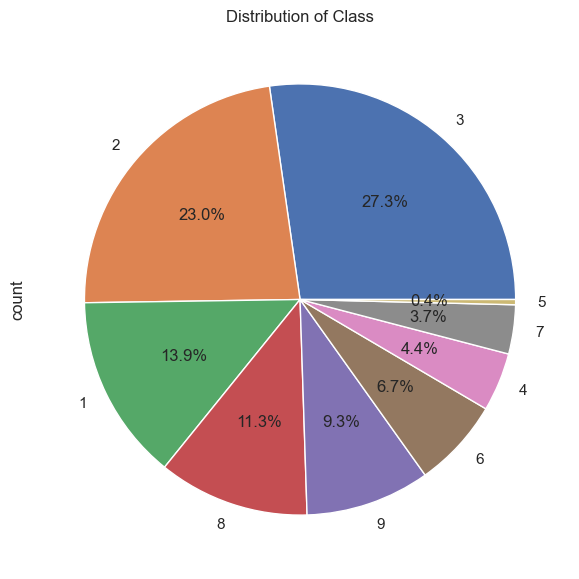

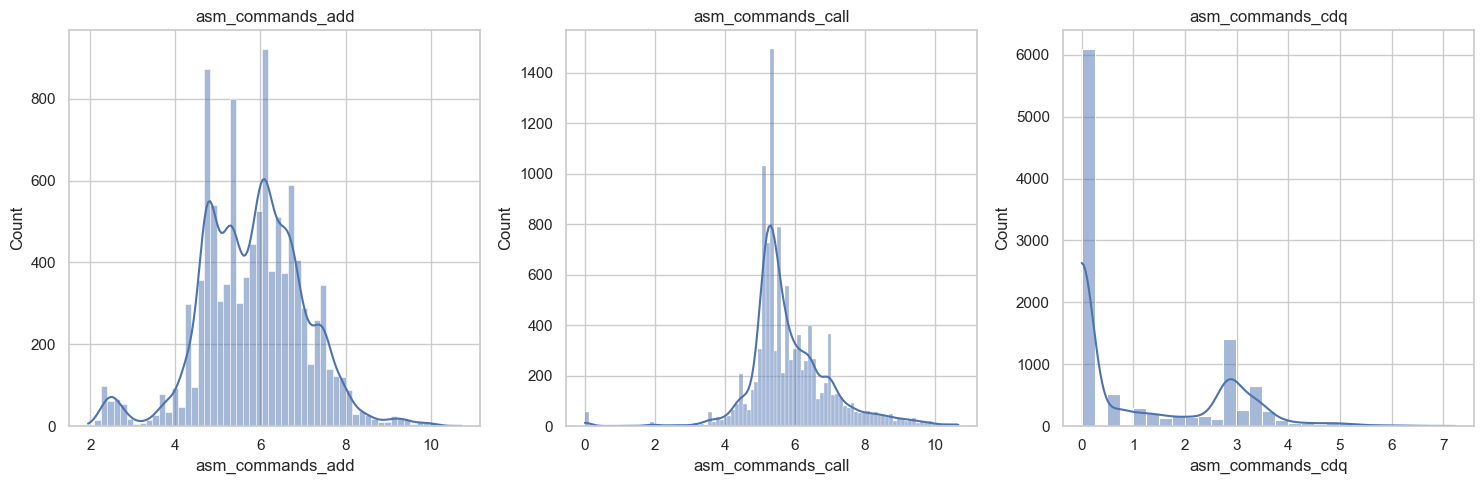

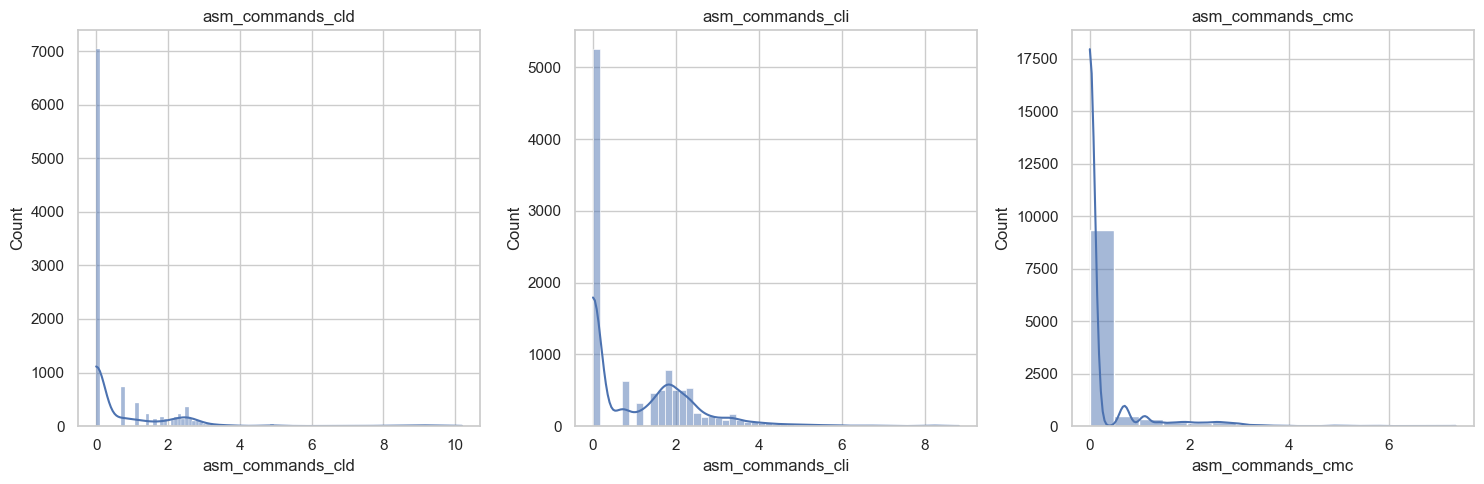

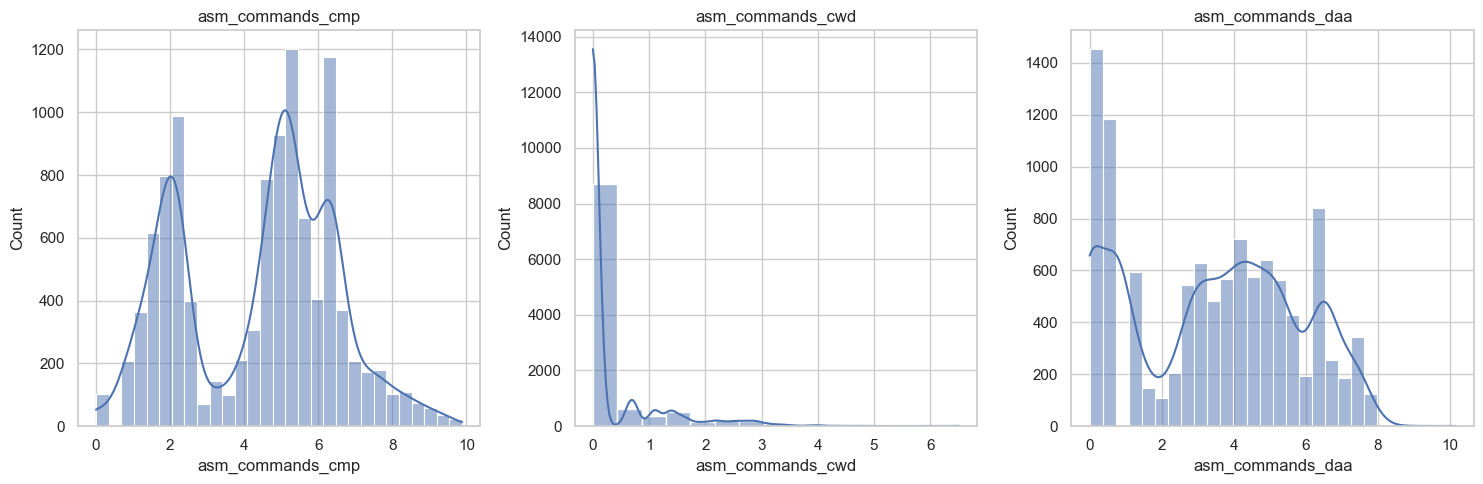

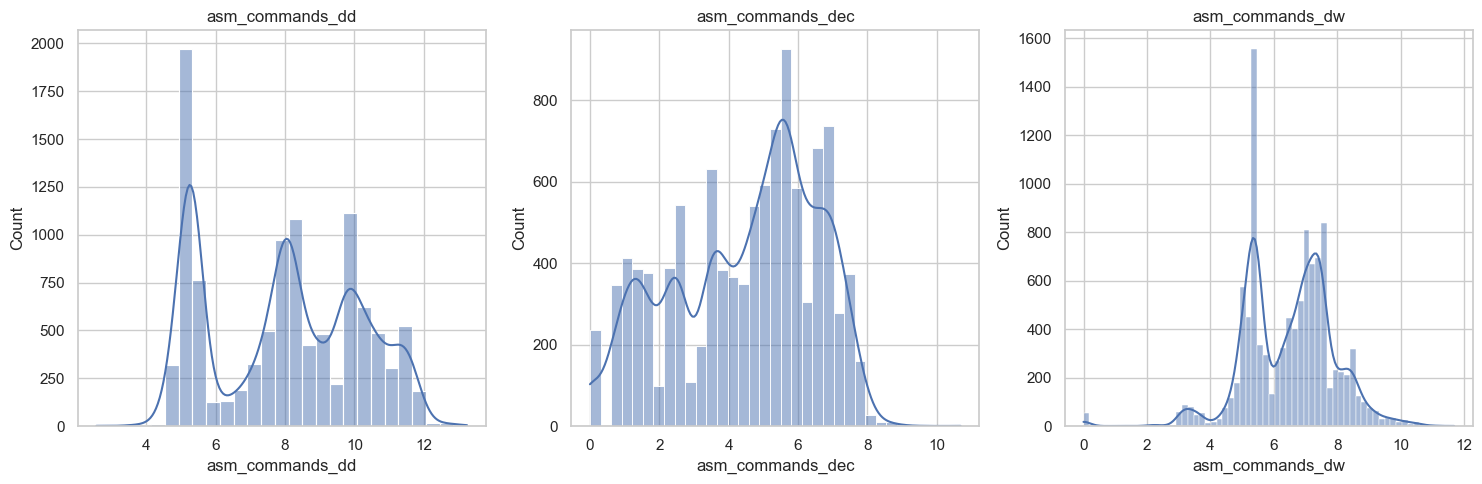

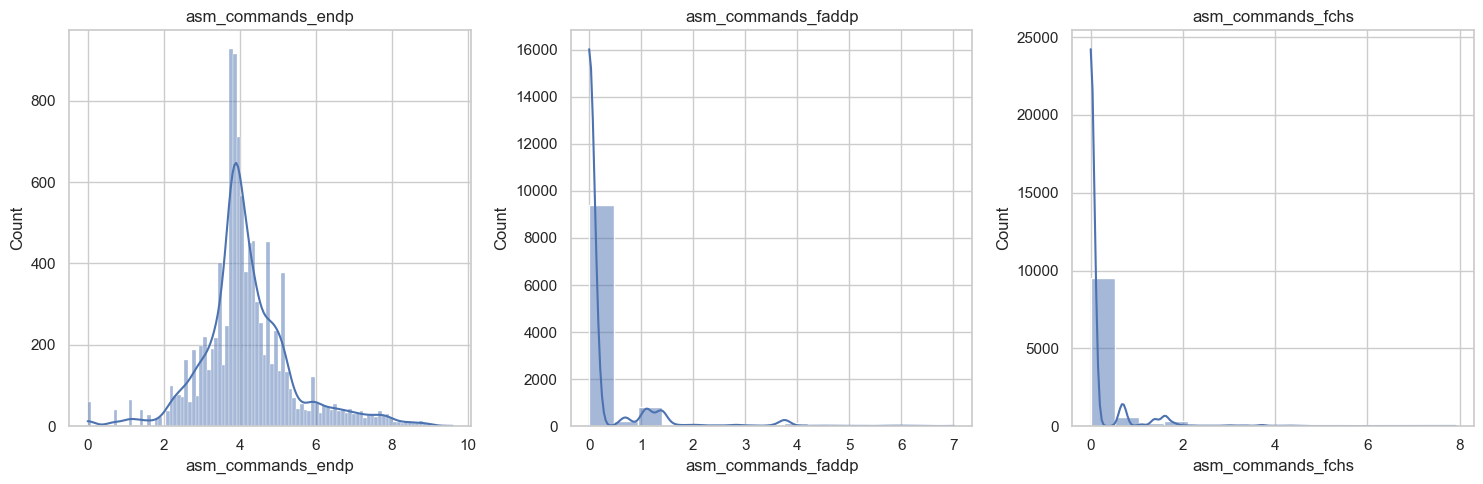

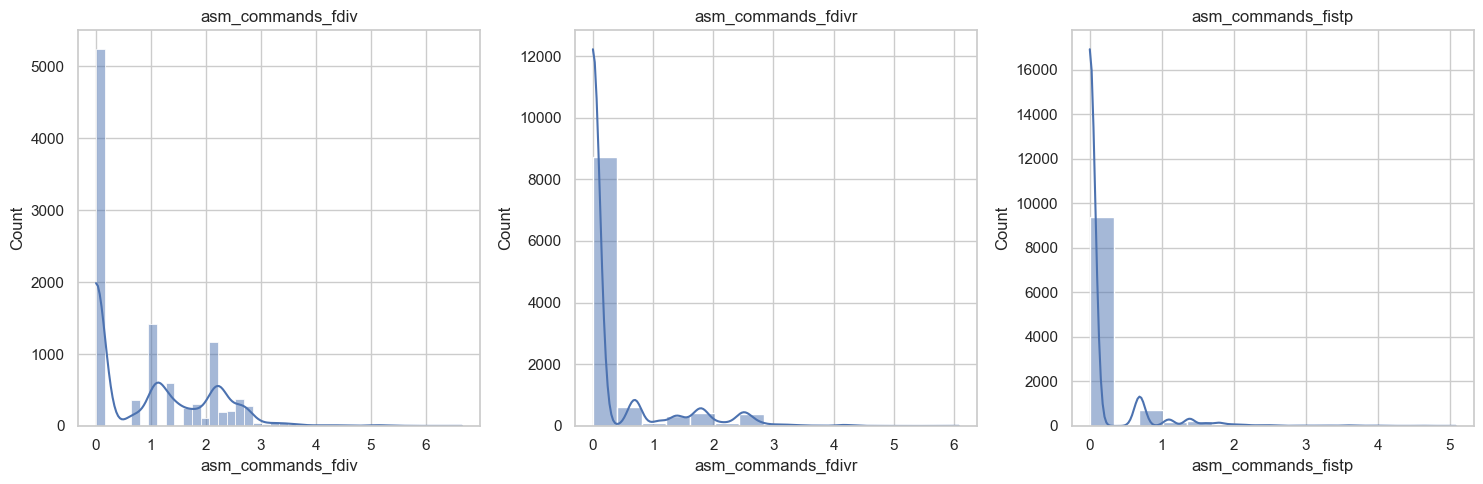

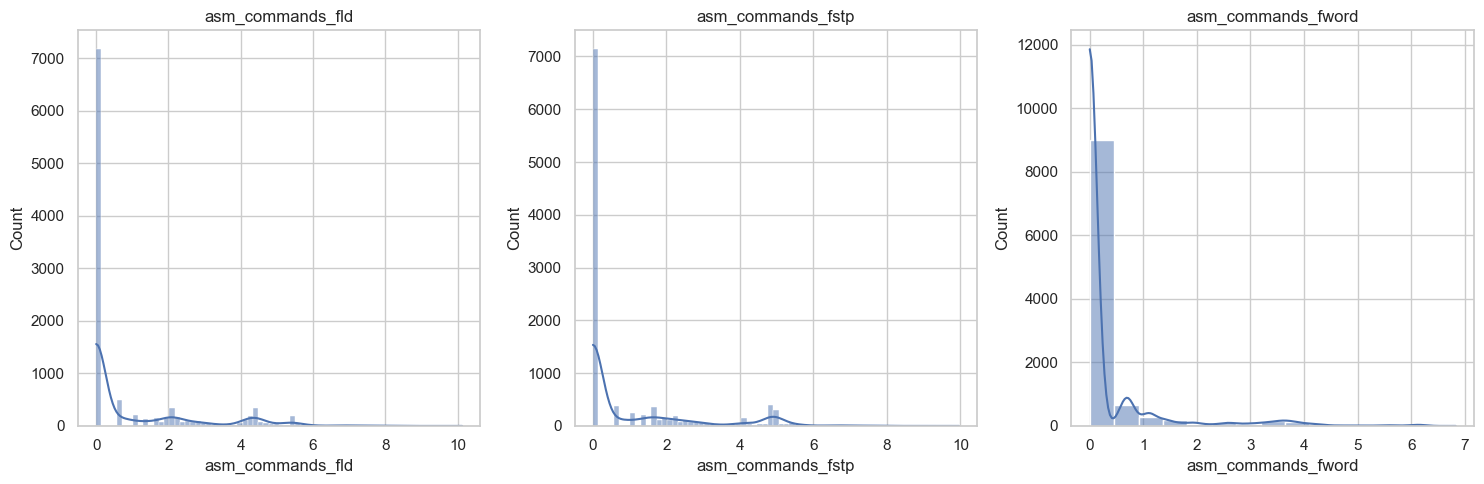

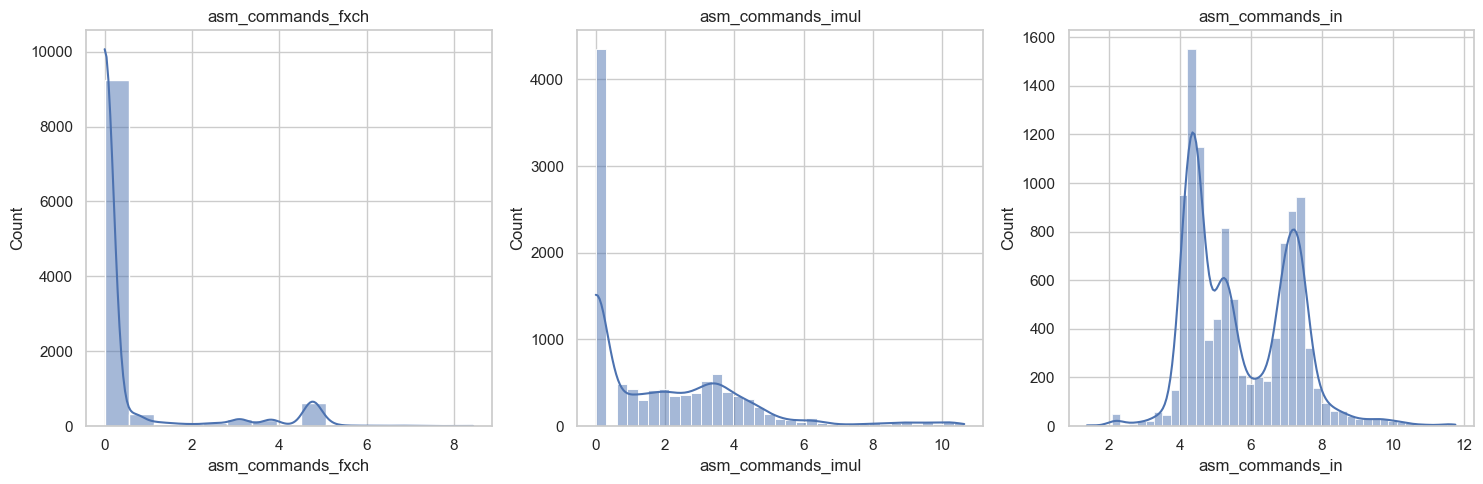

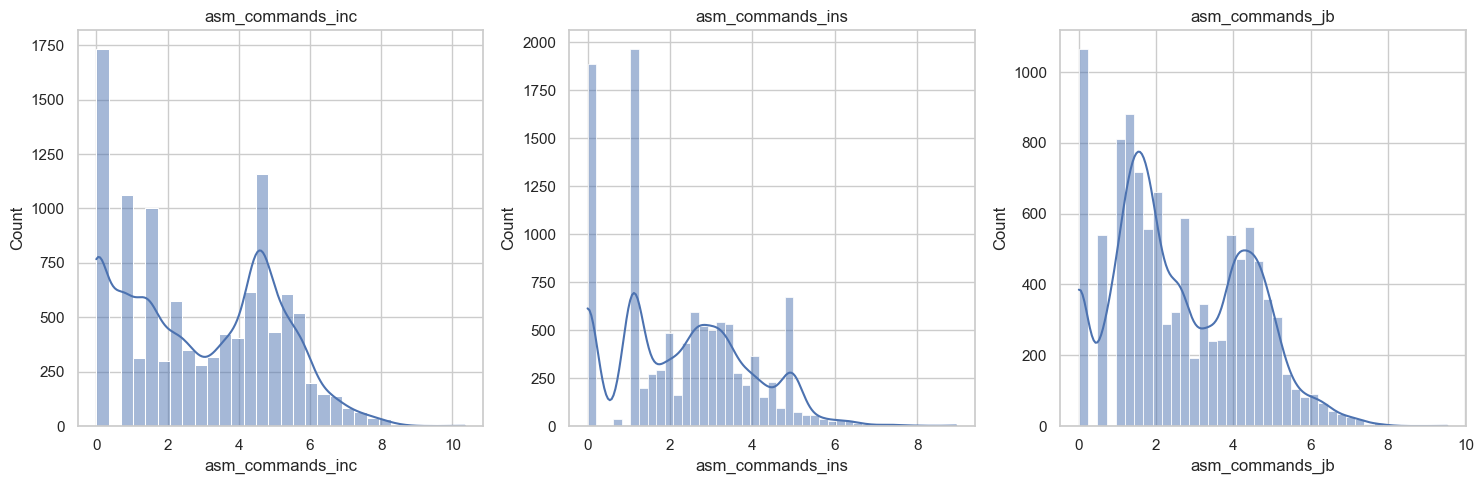

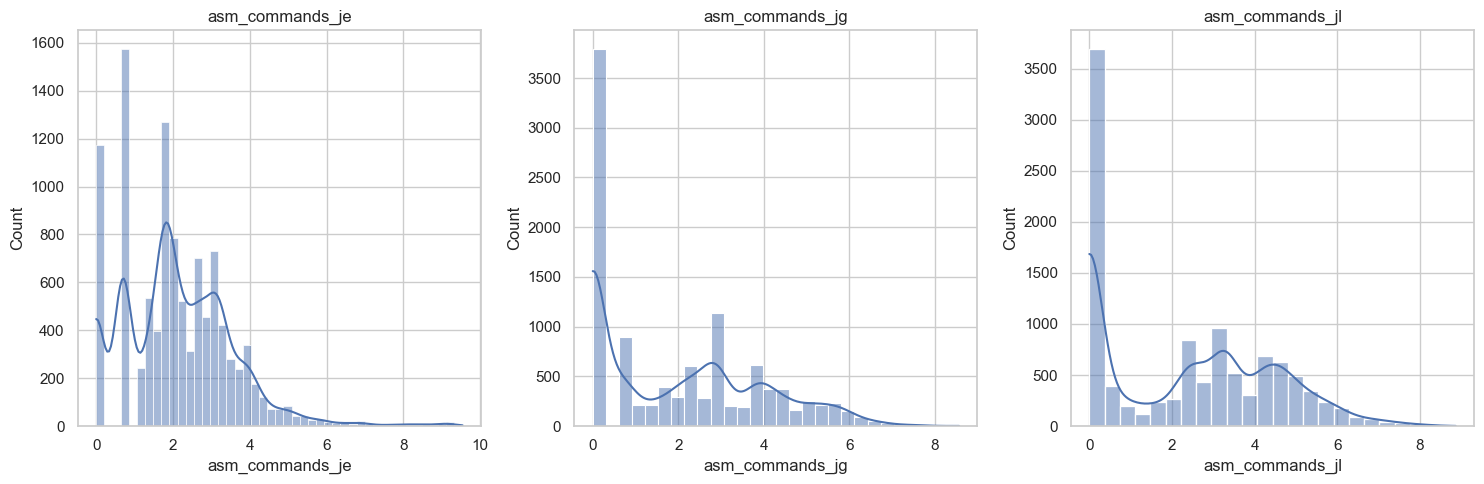

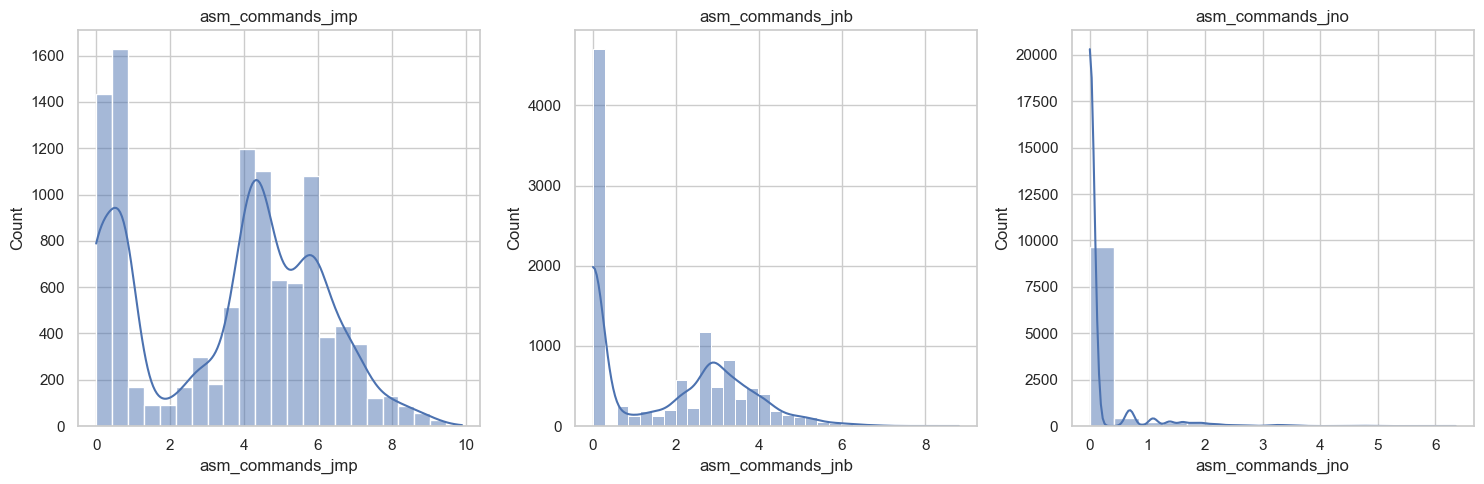

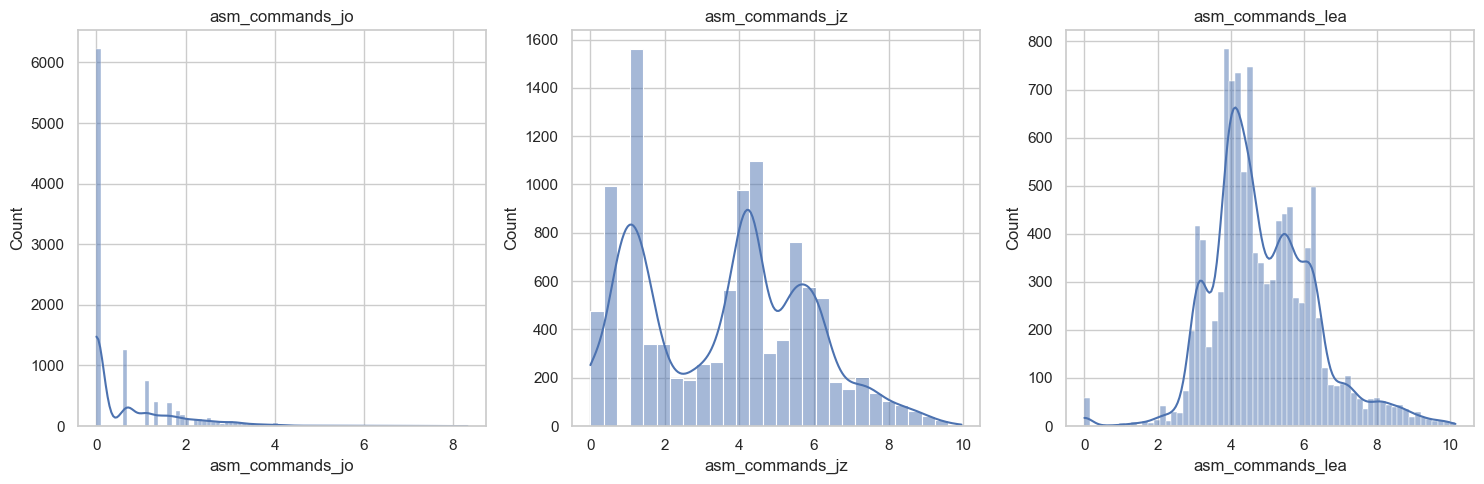

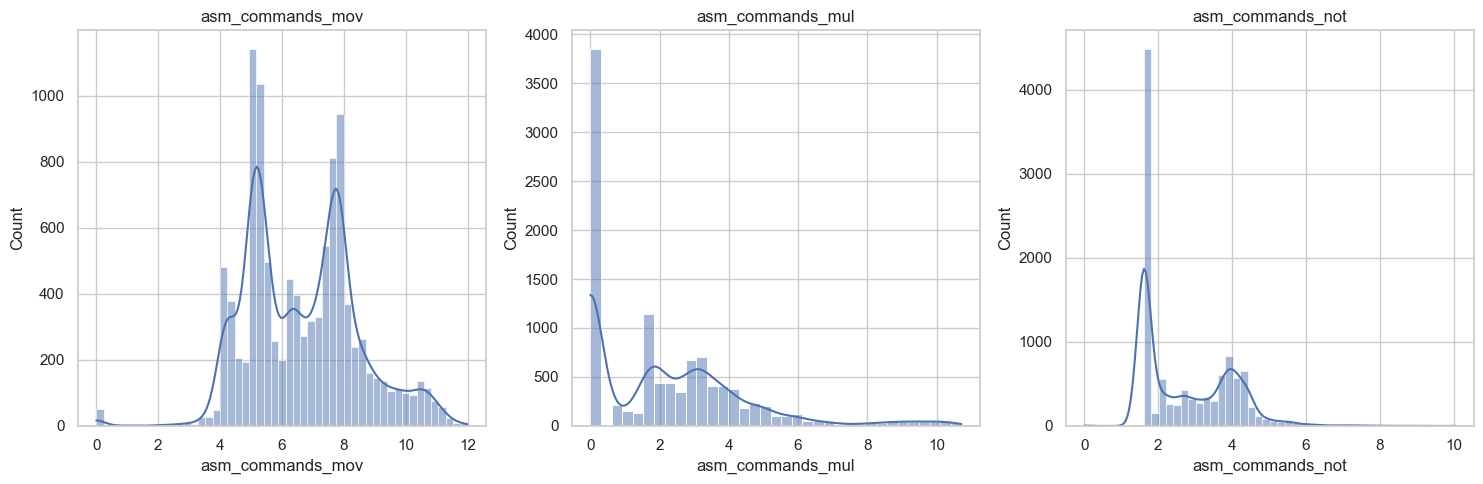

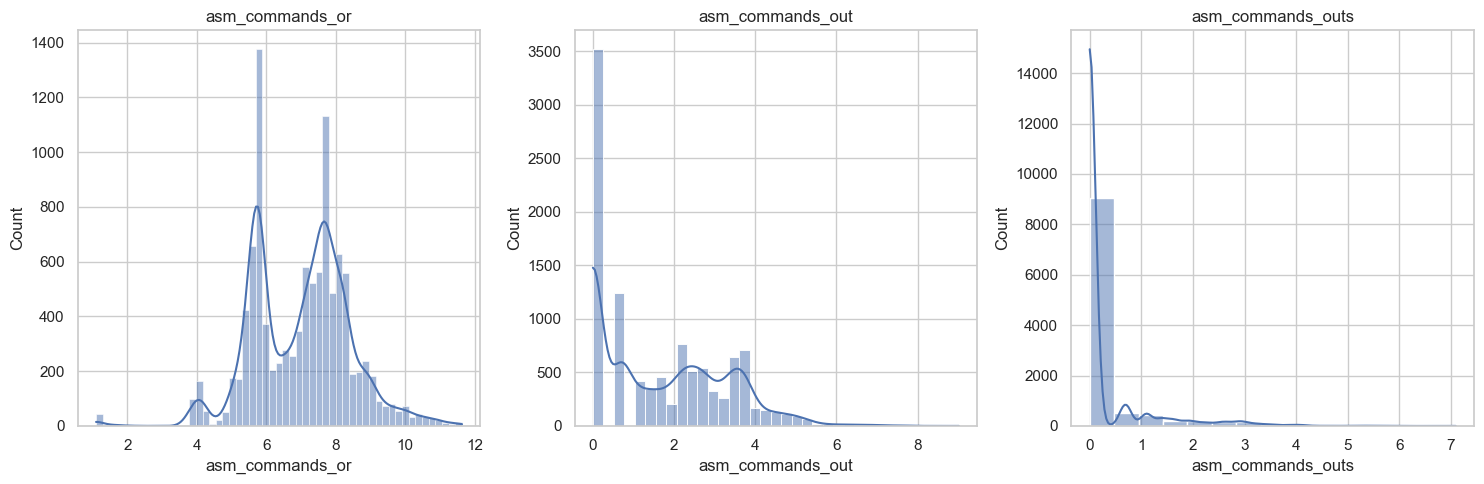

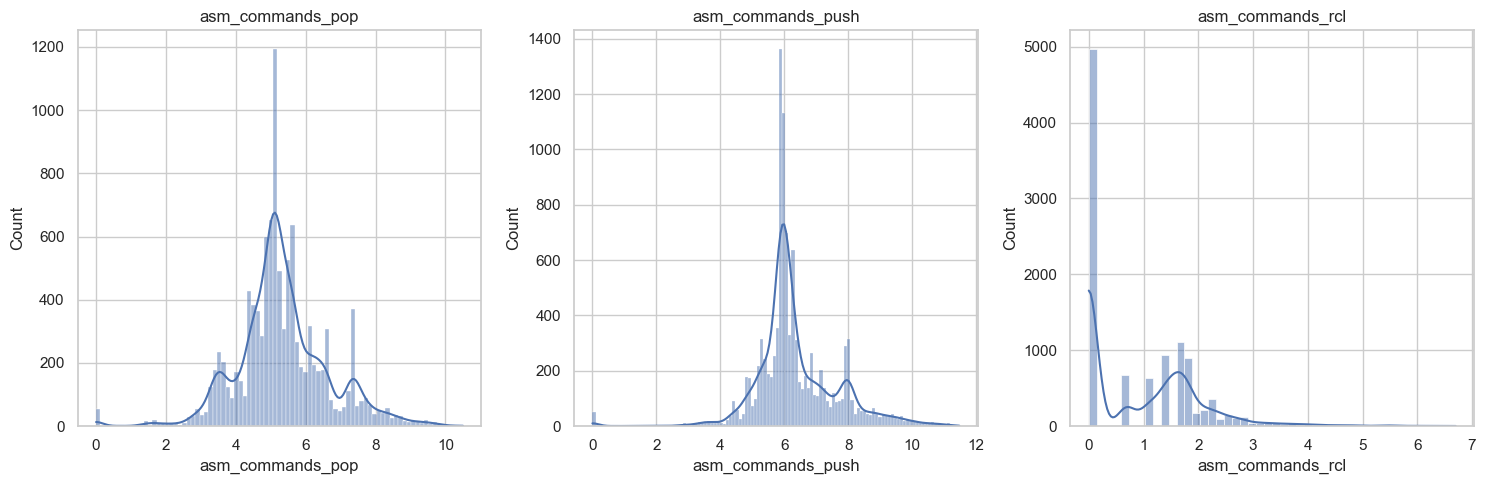

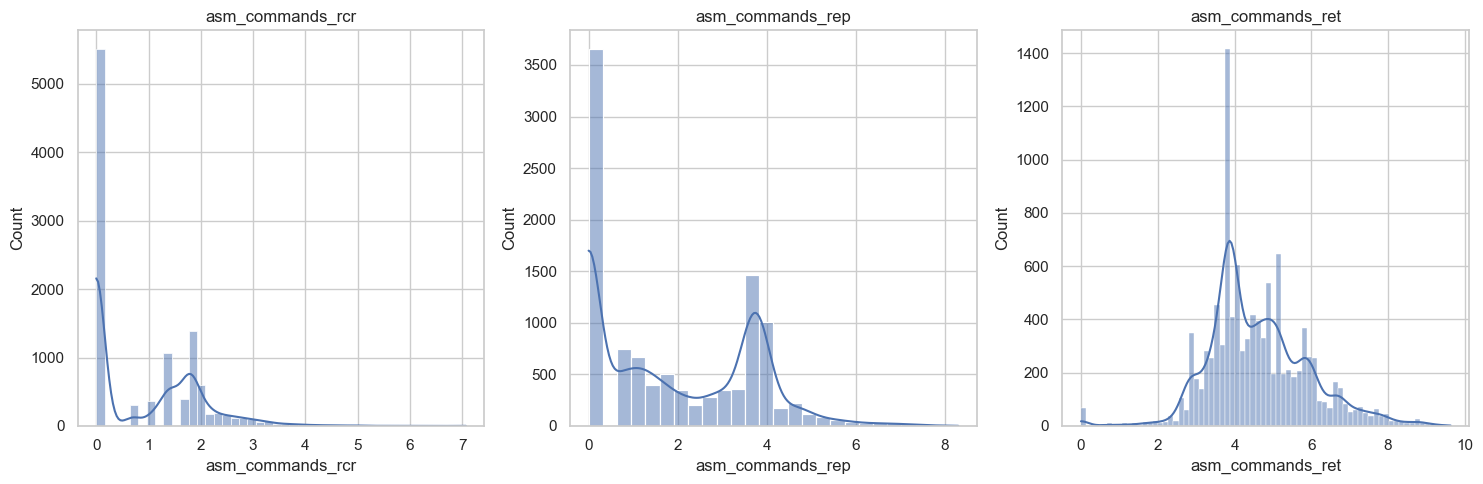

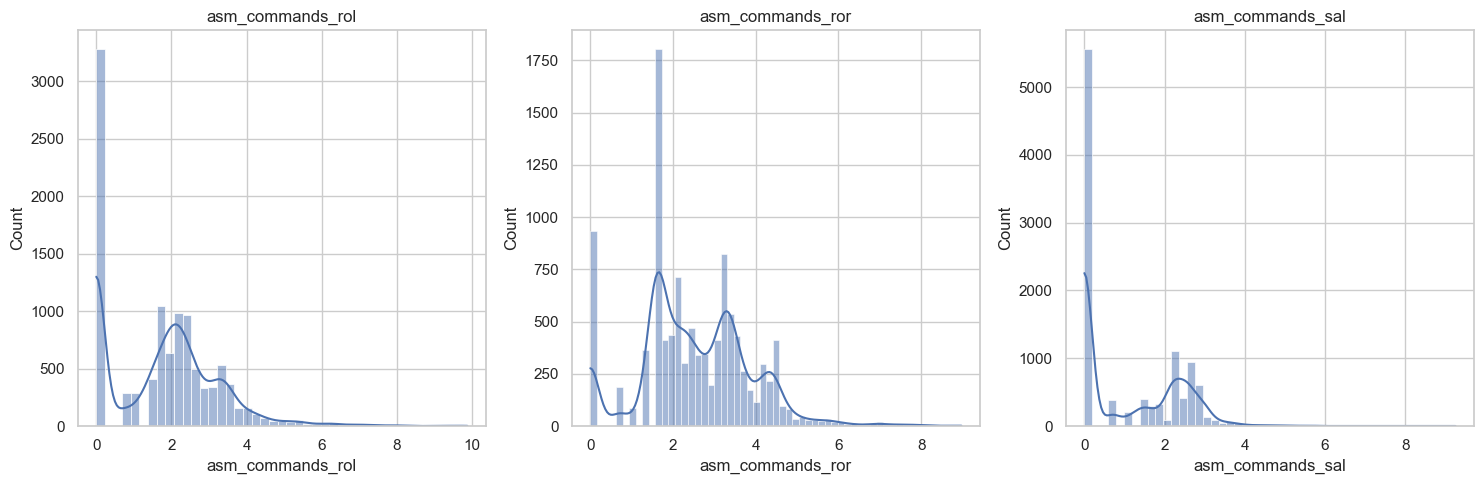

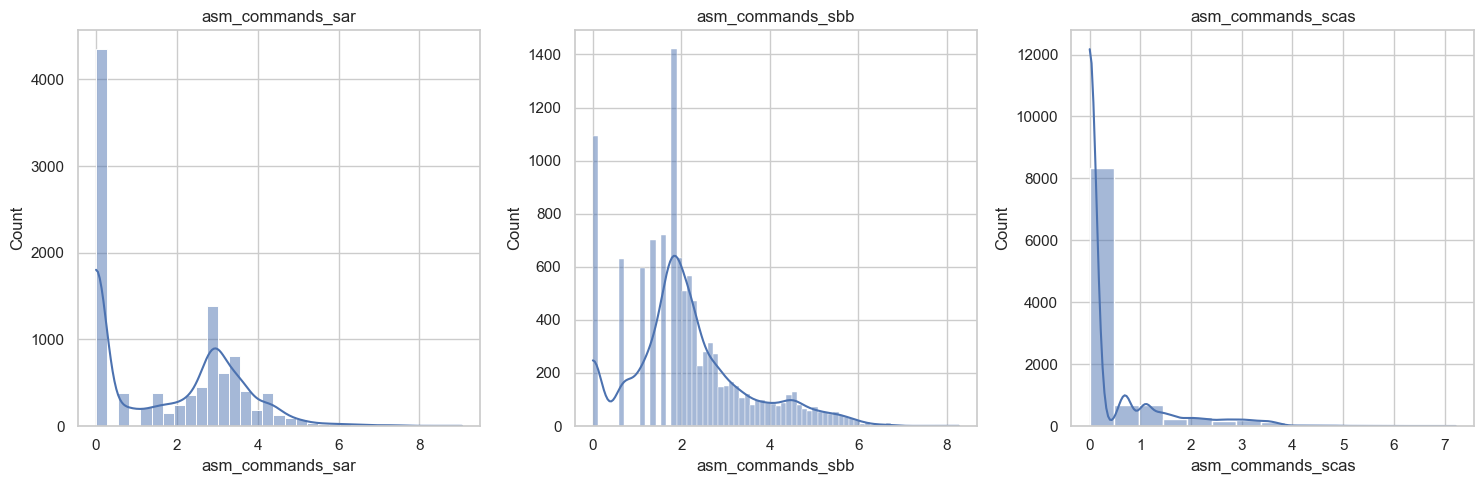

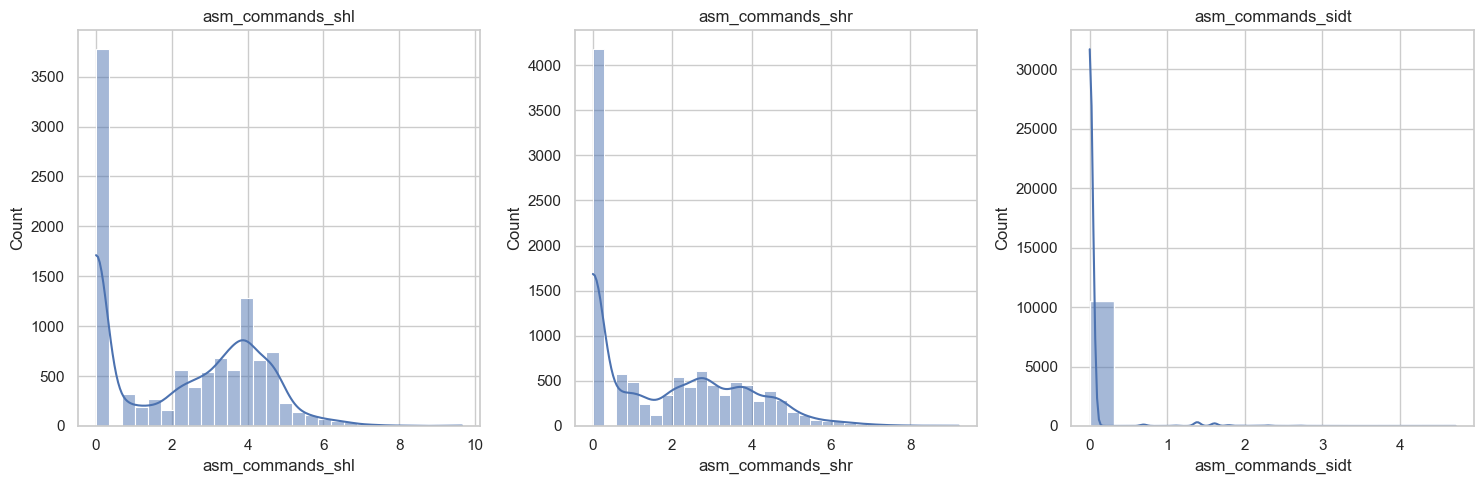

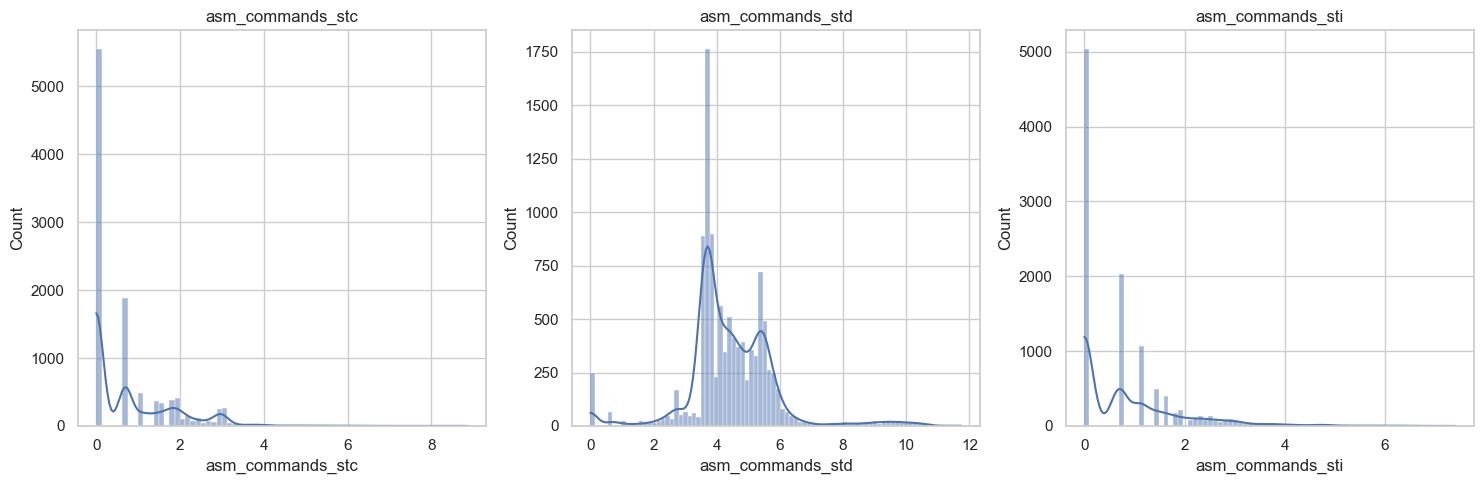

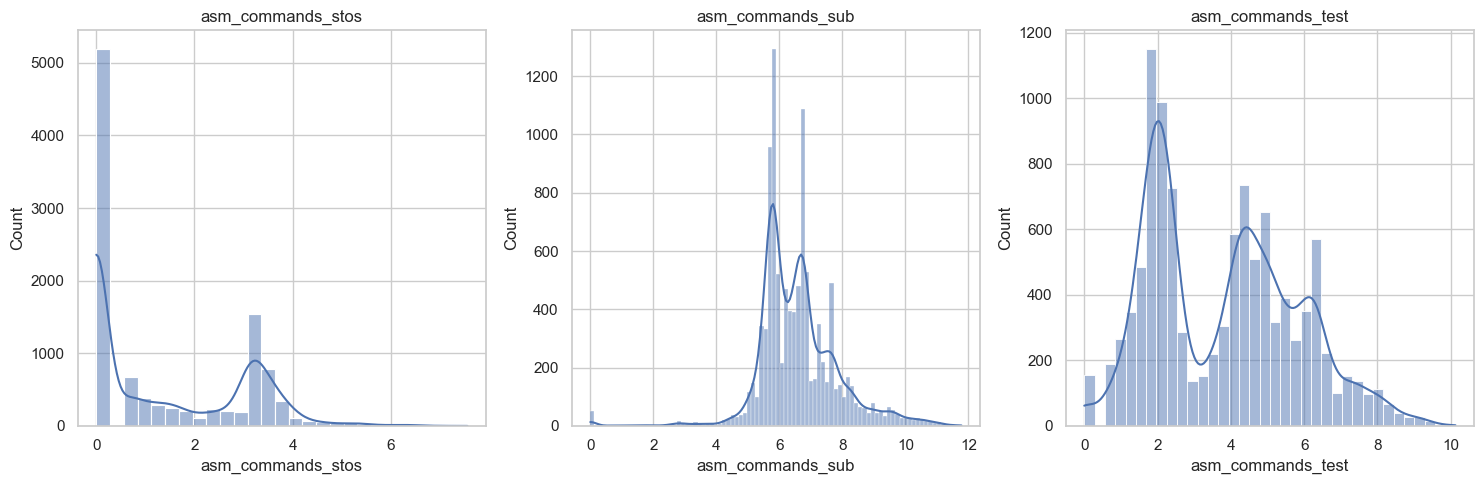

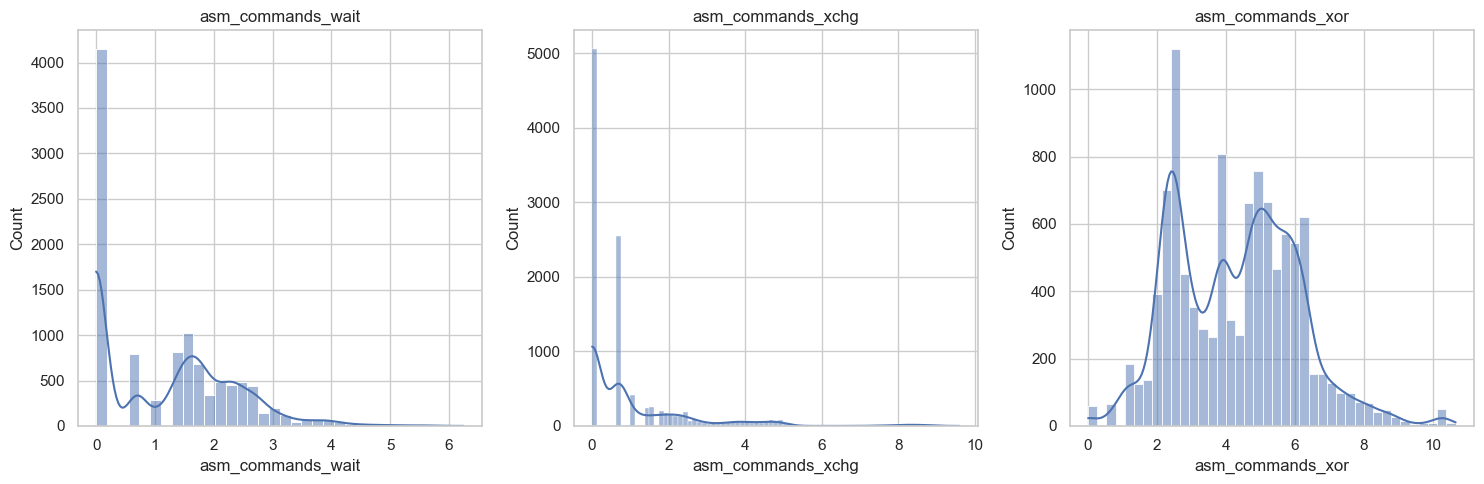

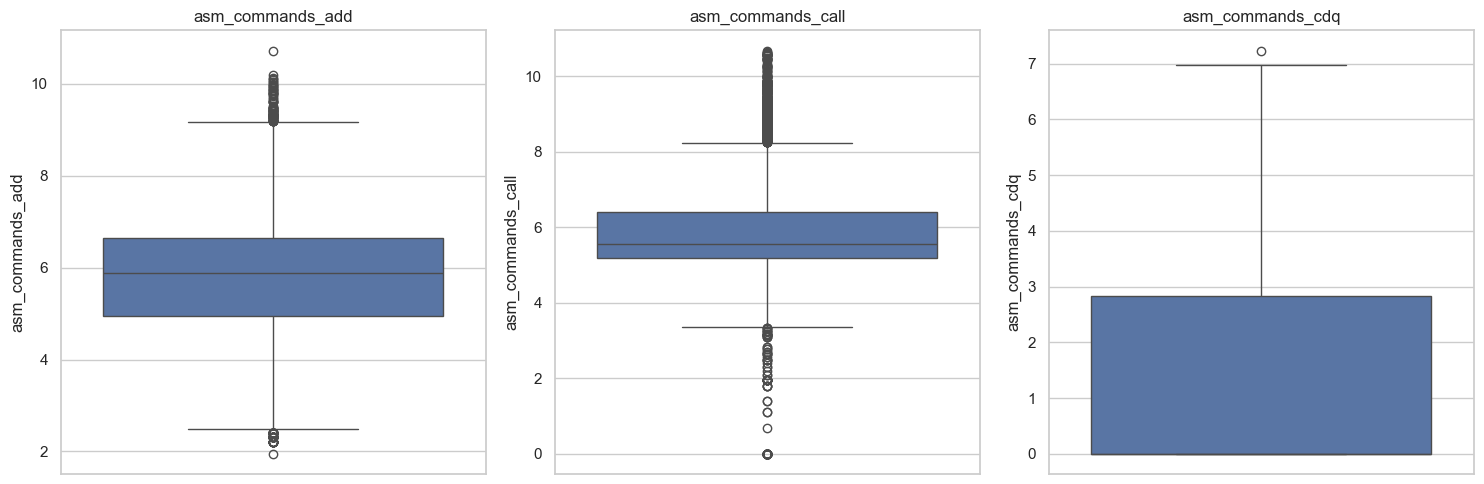

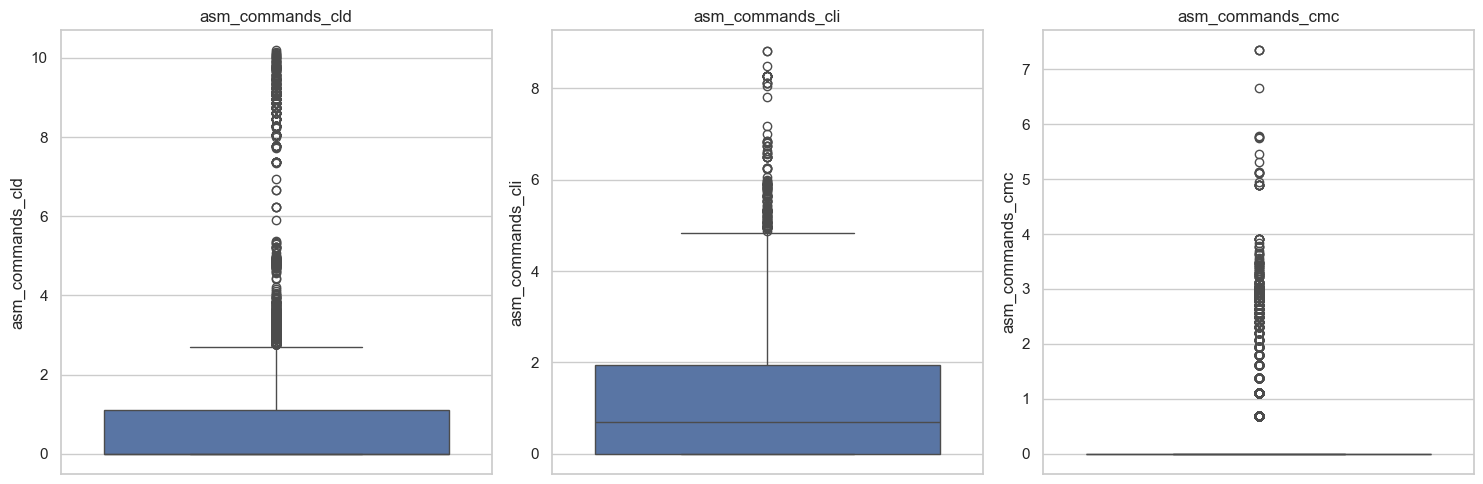

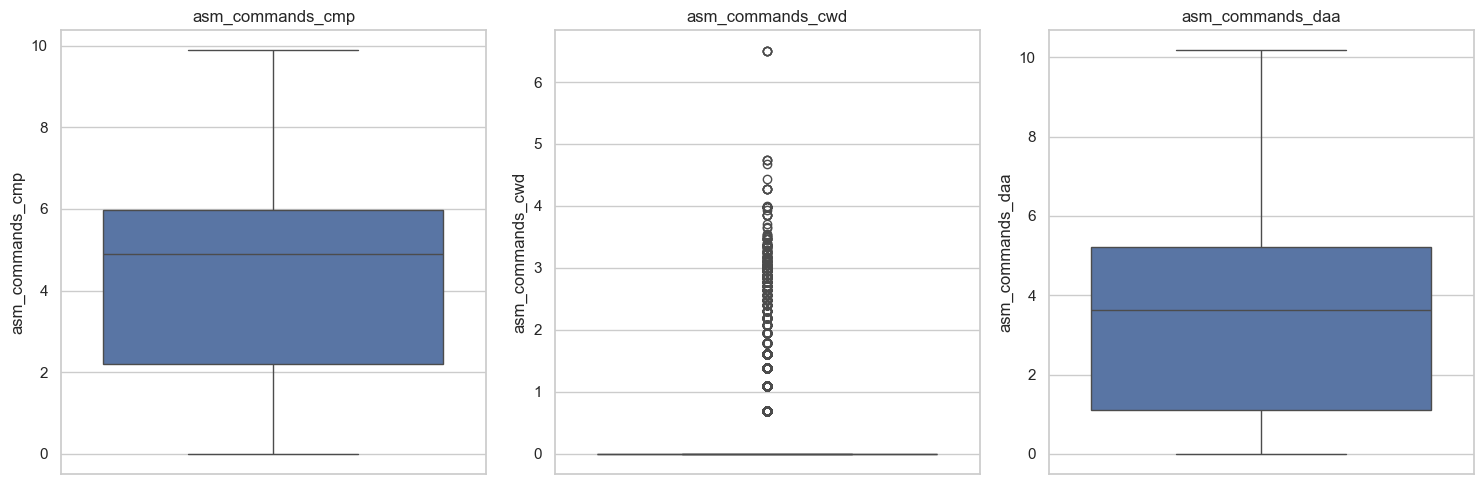

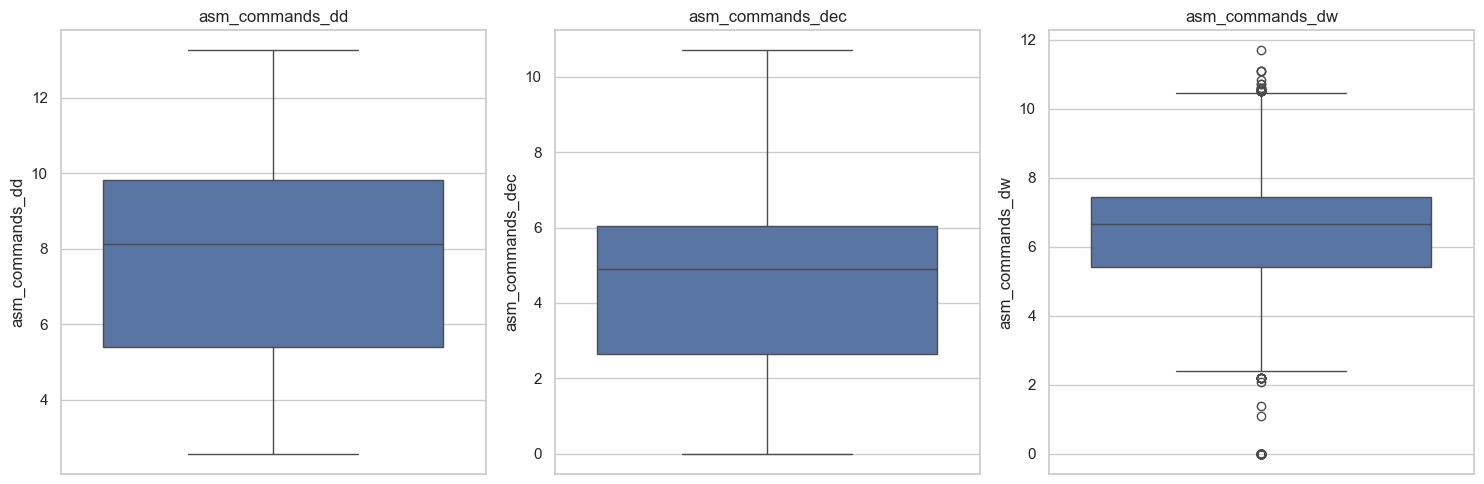

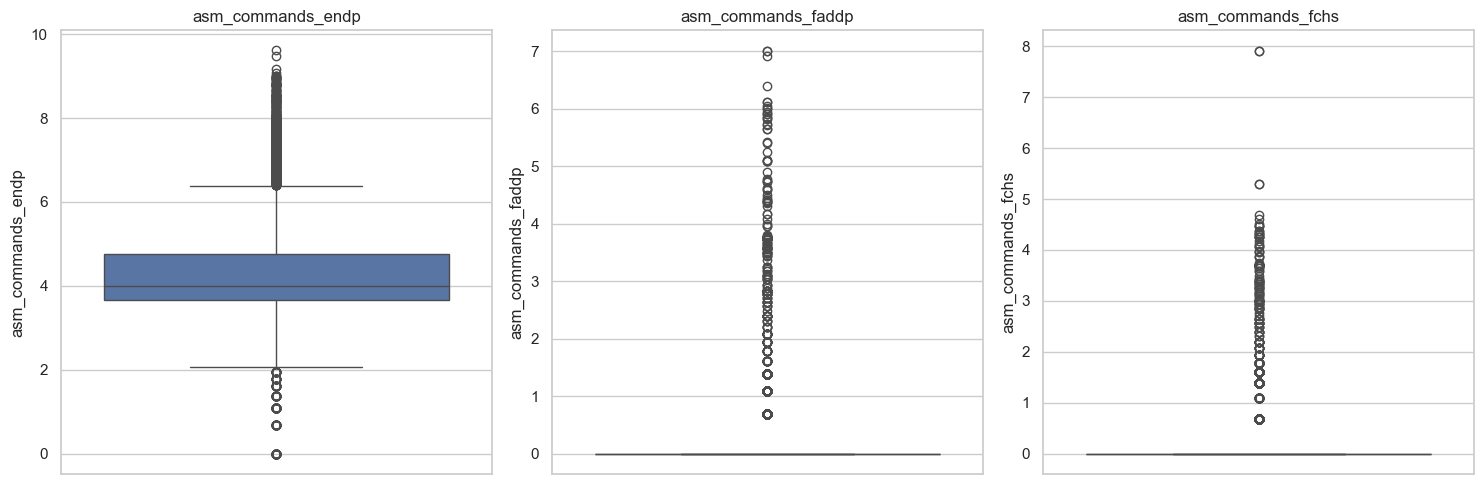

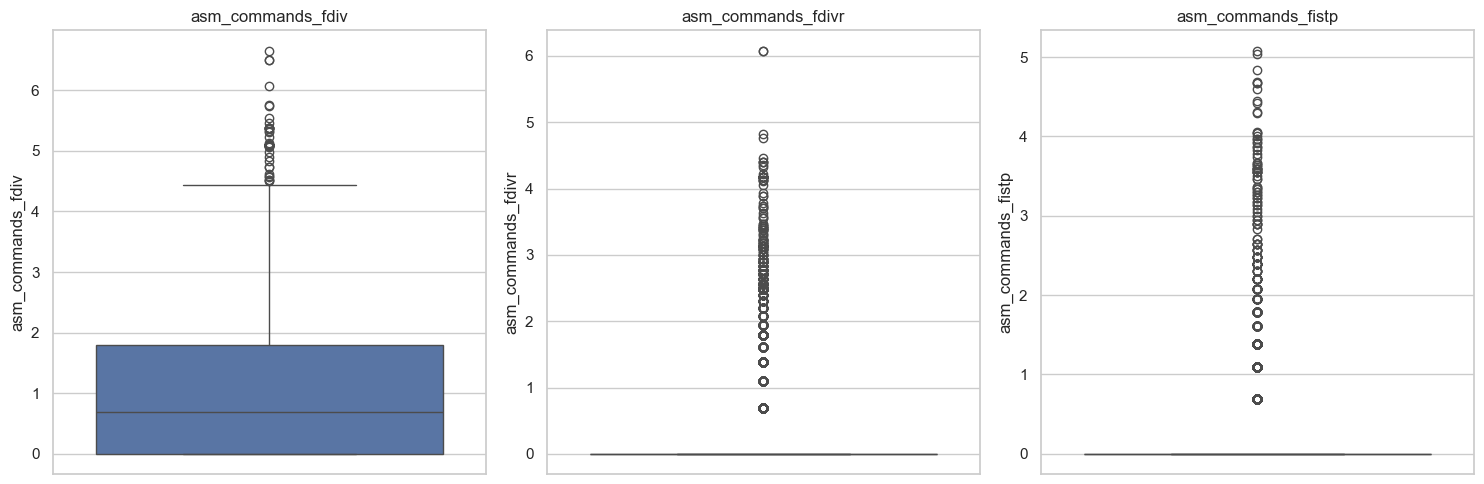

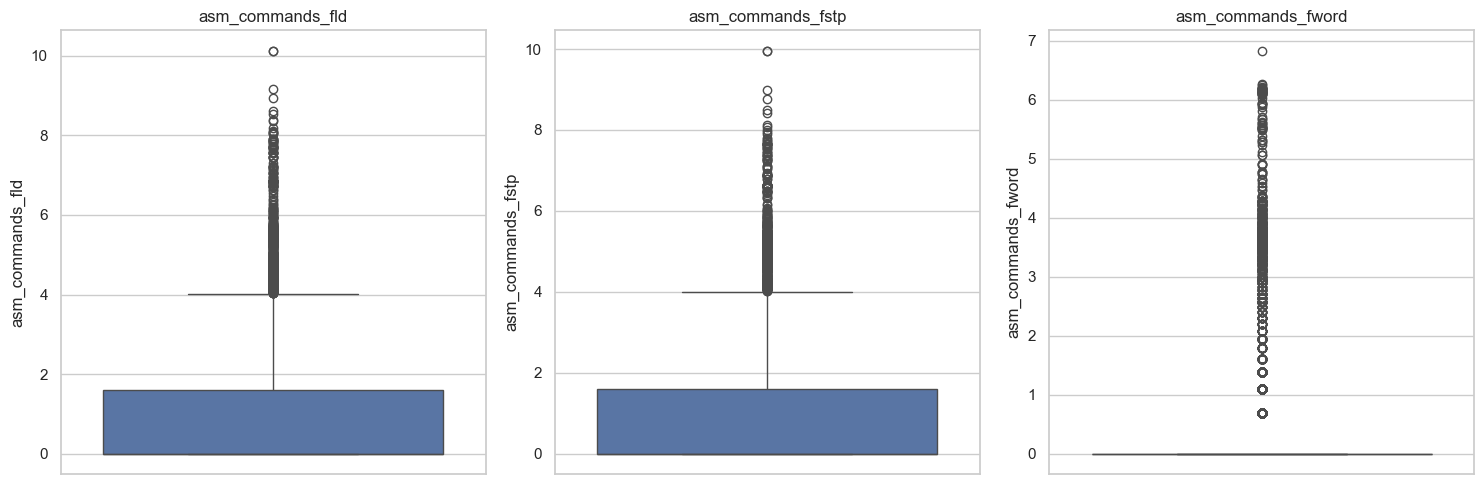

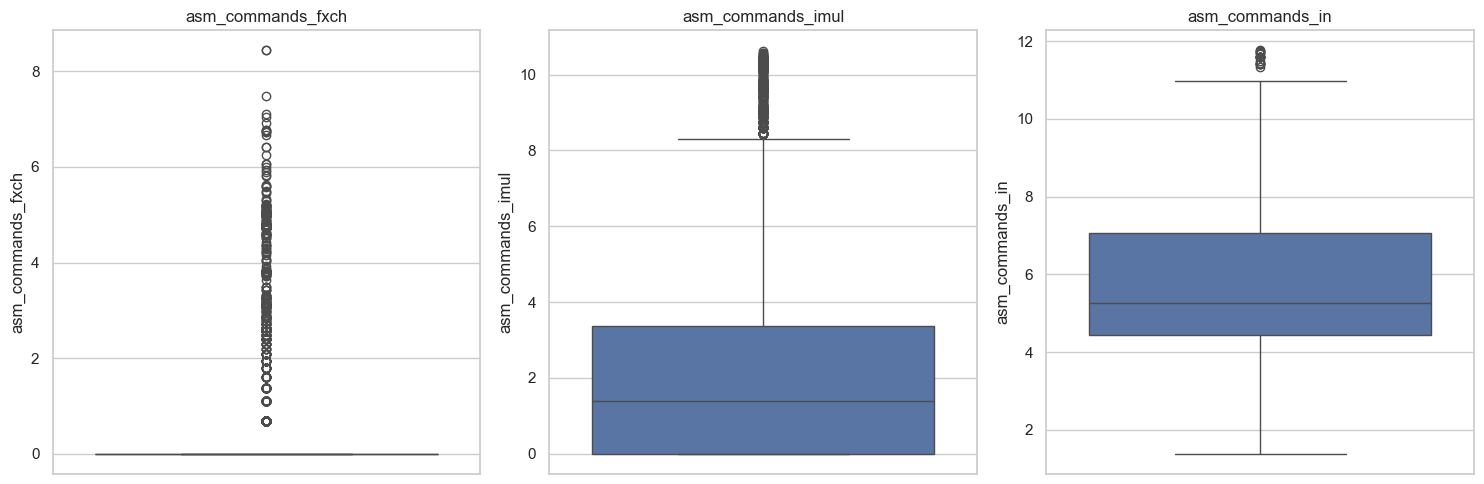

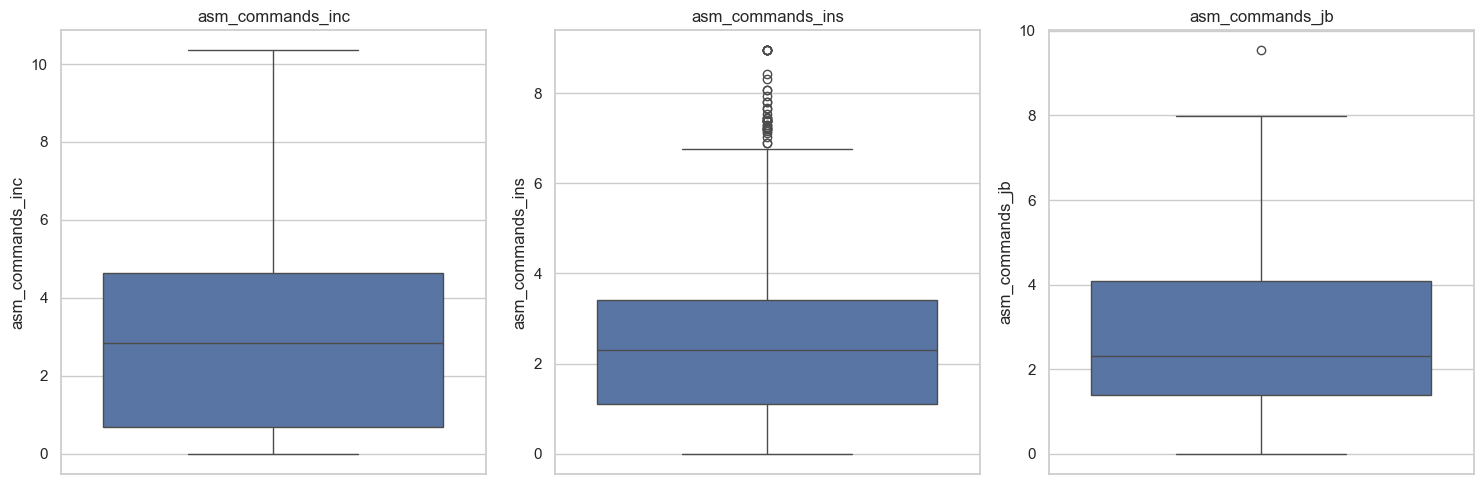

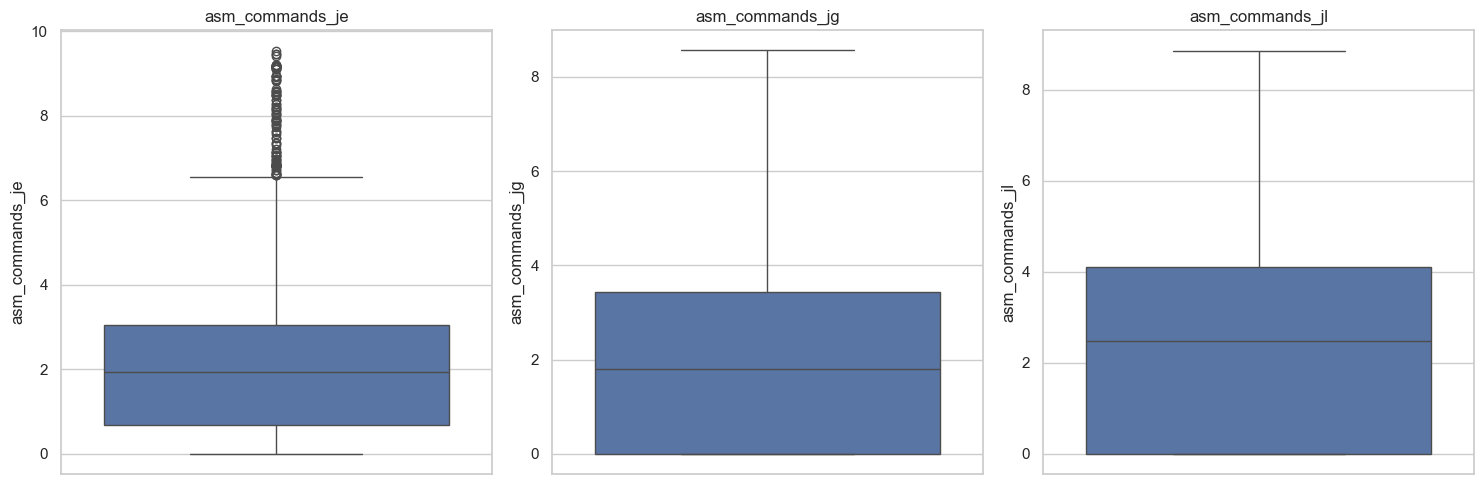

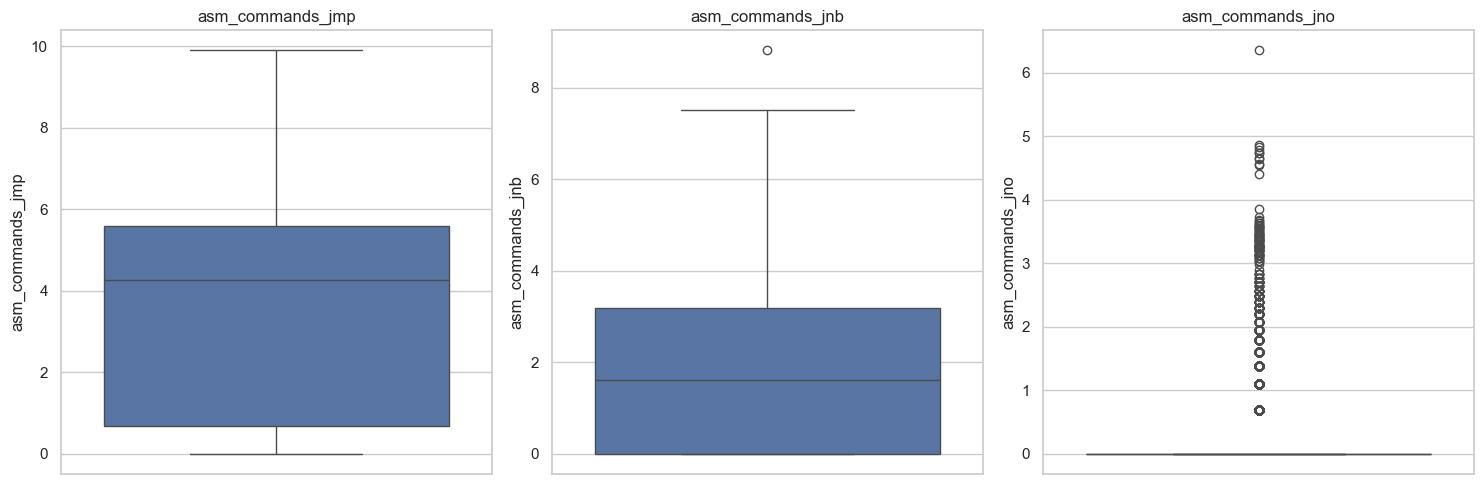

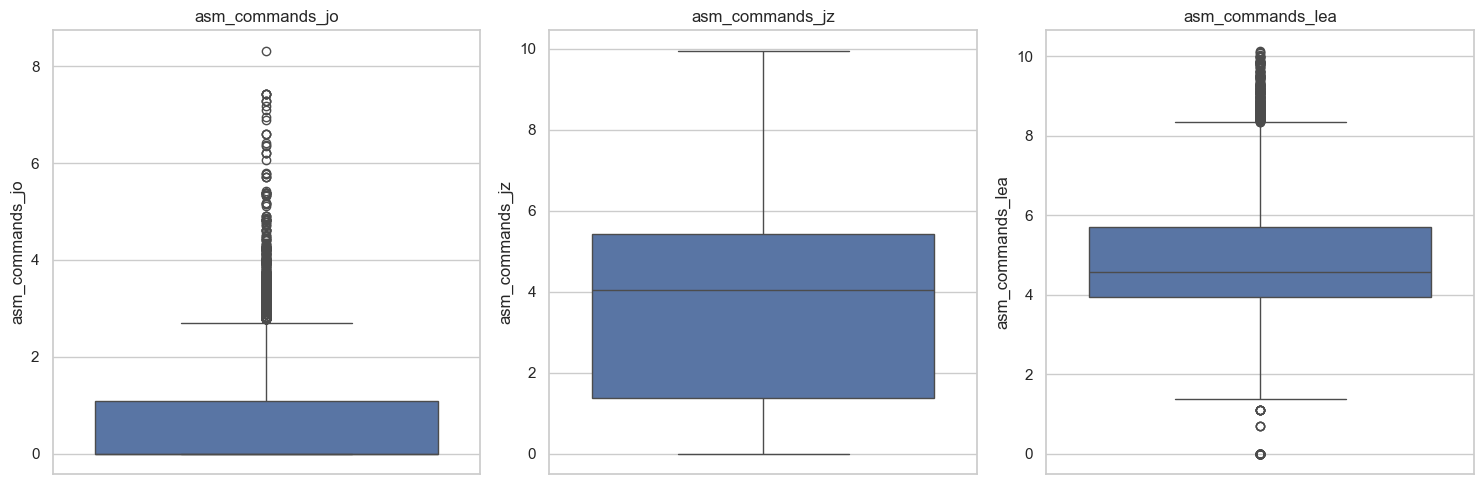

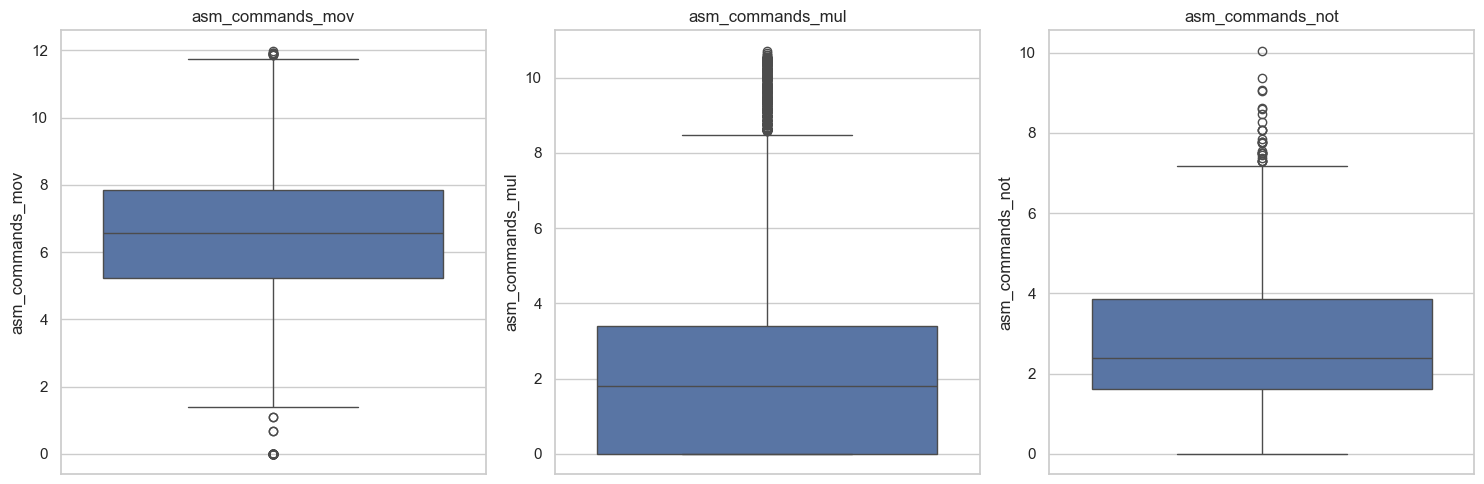

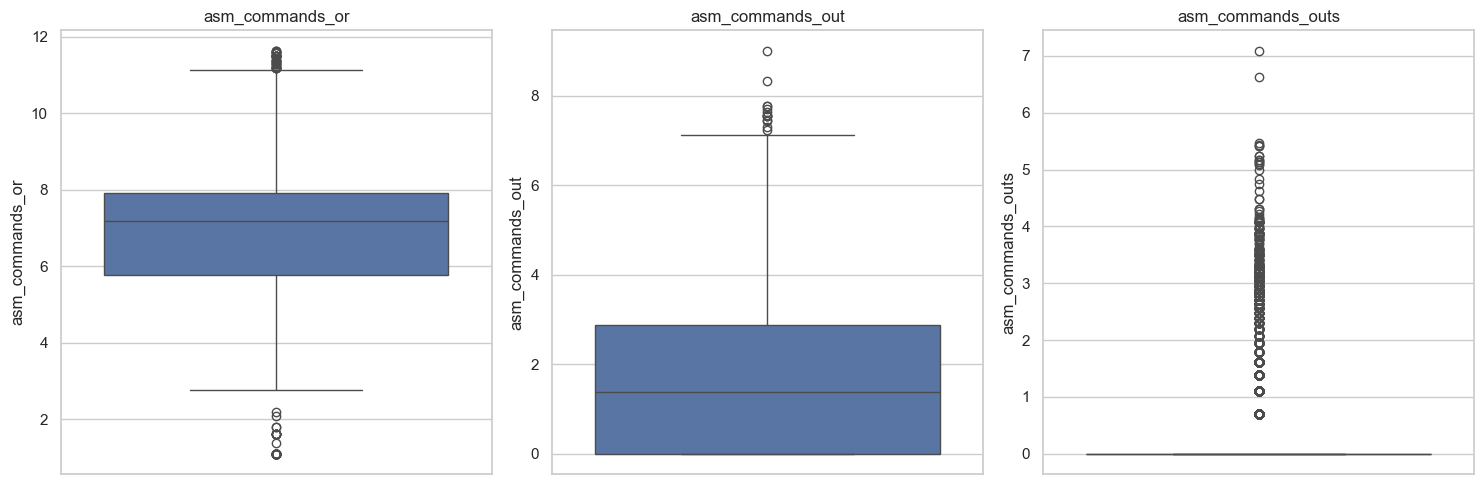

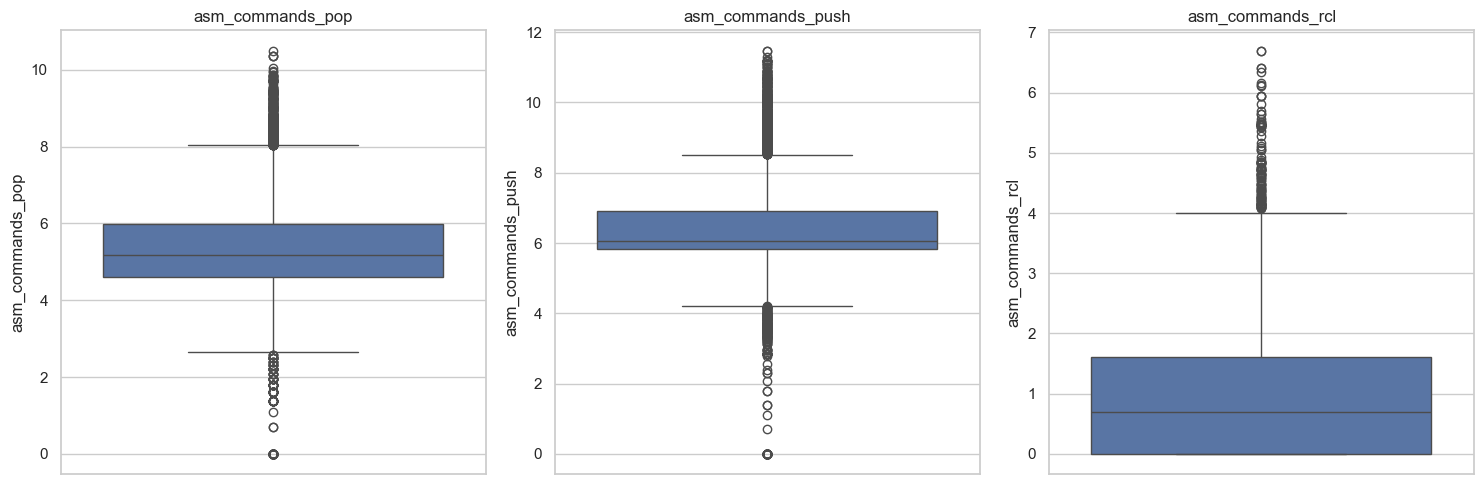

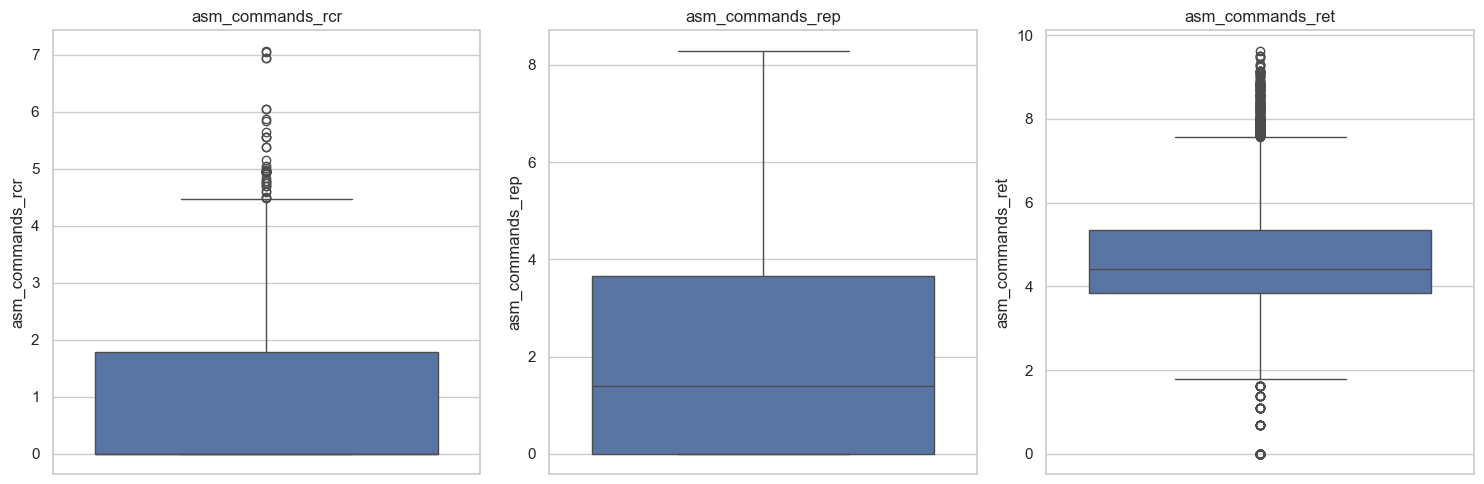

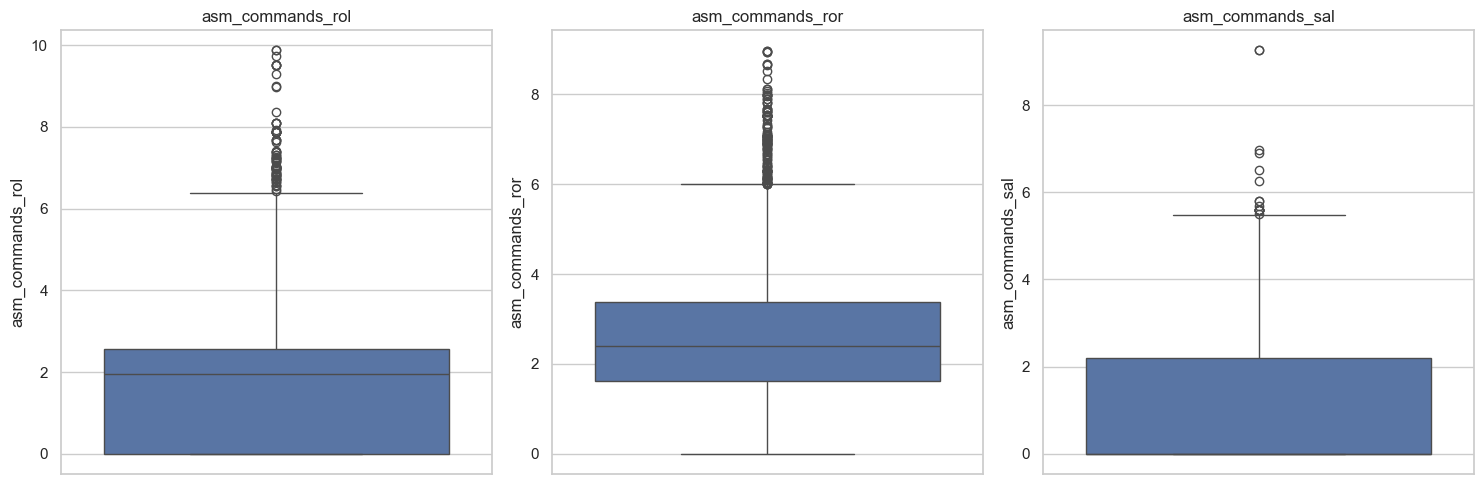

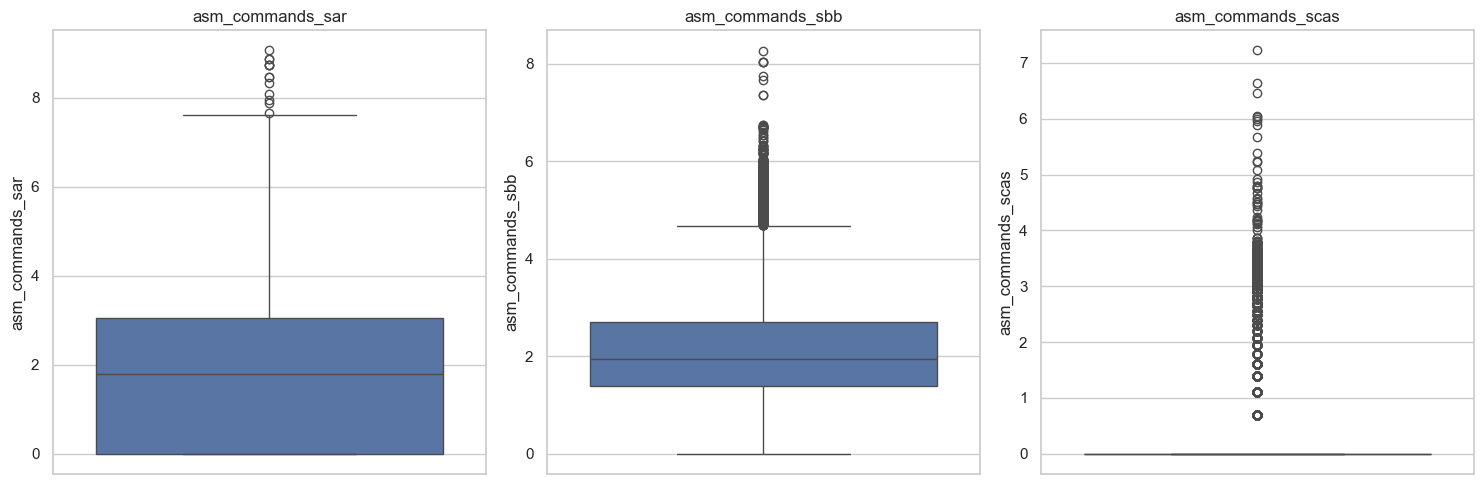

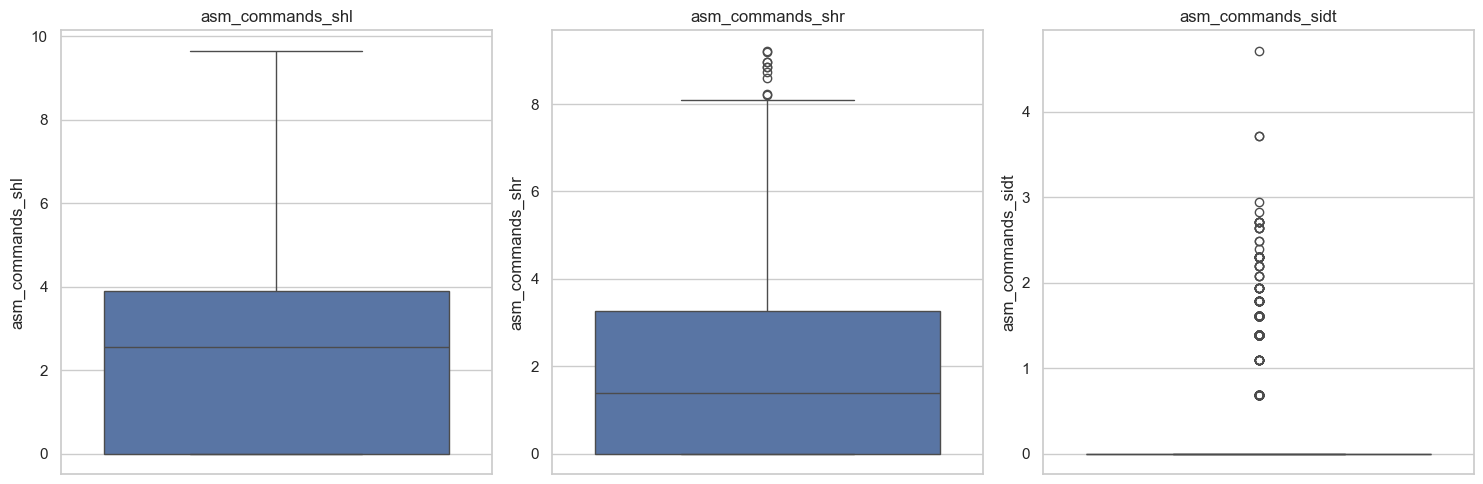

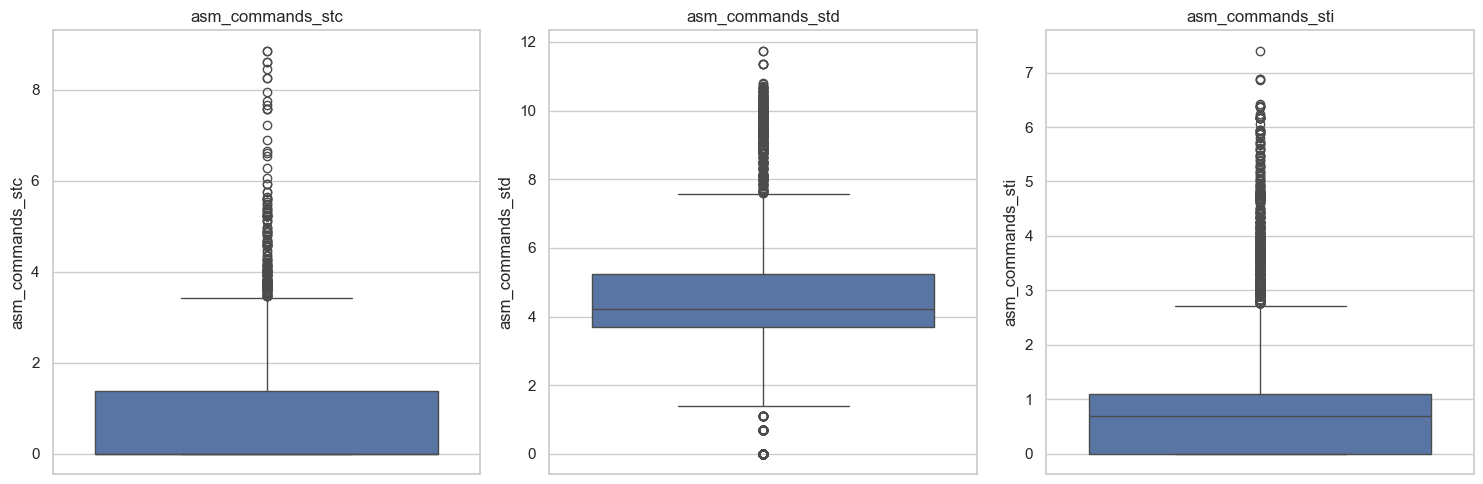

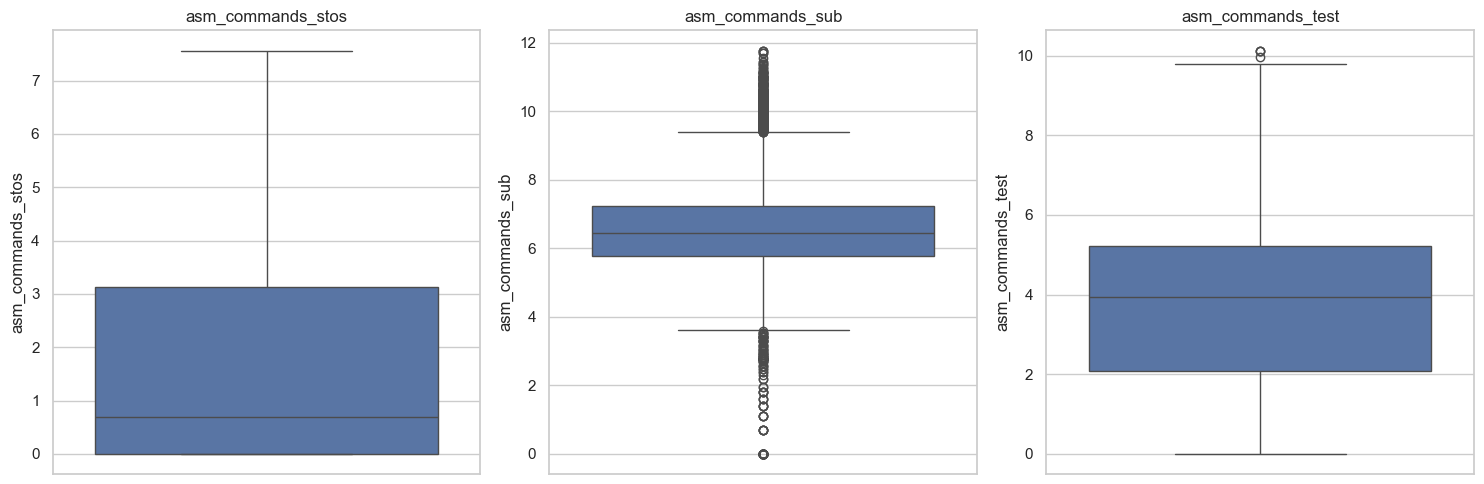

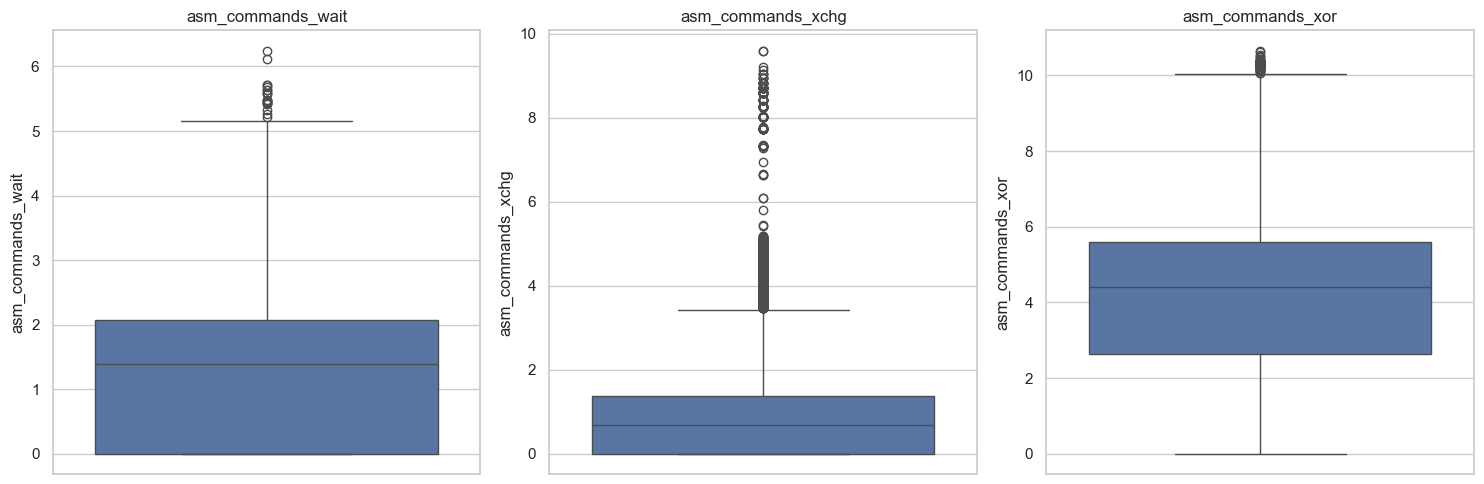

,asm_commands_add,asm_commands_call,asm_commands_cdq,asm_commands_cld,asm_commands_cli,asm_commands_cmc,asm_commands_cmp,asm_commands_cwd,asm_commands_daa,asm_commands_dd,...,asm_commands_sti,asm_commands_stos,asm_commands_sub,asm_commands_test,asm_commands_wait,asm_commands_xchg,asm_commands_xor,line_count_asm,size_asm,Class
count,10788.000000,10788.000000,10788.000000,10788.000000,10788.000000,10788.000000,10788.000000,10788.000000,10788.000000,10788.000000,...,10788.000000,10788.000000,10788.000000,10788.000000,10788.000000,10788.000000,10788.000000,10788.000000,1.078800e+04,10788.000000
mean,722.412032,940.680664,10.727938,201.669448,16.569707,1.608825,470.585280,1.412959,222.040879,17059.766871,...,6.013904,14.469040,2146.519466,324.672136,6.169633,72.215054,491.001020,81098.112625,4.703634e+06,4.017798
std,1565.942971,2824.018700,39.102529,1573.488017,184.668595,28.225494,1350.661835,13.750310,499.829398,32996.975978,...,36.427038,48.012215,6679.766701,1091.361857,16.838353,583.607571,2474.199527,64487.347871,3.740266e+06,2.682628
min,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1942.000000,1.126280e+05,1.000000
25%,140.000000,178.000000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,2.000000,217.000000,...,0.000000,0.000000,322.000000,7.000000,0.000000,0.000000,13.000000,15105.000000,8.760320e+05,2.000000
50%,362.000000,261.000000,0.000000,0.000000,1.000000,0.000000,134.000000,0.000000,37.000000,3332.000000,...,1.000000,1.000000,640.000000,50.000000,3.000000,1.000000,81.000000,75840.000000,4.398706e+06,3.000000
75%,766.000000,607.000000,16.000000,2.000000,6.000000,0.000000,393.000000,0.000000,184.000000,18266.000000,...,2.000000,22.000000,1376.250000,183.000000,7.000000,3.000000,270.250000,146433.000000,8.493056e+06,6.000000
max,45684.000000,43479.000000,1384.000000,26600.000000,6830.000000,1540.000000,19617.000000,670.000000,26147.000000,565024.000000,...,1641.000000,1924.000000,130324.000000,25008.000000,515.000000,14725.000000,42457.000000,963585.000000,5.588787e+07,9.000000


In [54]:
plt.figure(1, figsize=(7,7), dpi = 100)
plt.title("Distribution of Class")
df['Class'].value_counts().plot.pie(autopct="%1.1f%%")

correlation_matrix = df.corr()
for col in correlation_matrix.columns:
    high_corr = correlation_matrix[col][(abs(correlation_matrix[col]) > 0.8) & (correlation_matrix.index != col)]
    if not high_corr.empty:
        print(f"\n Attributi con correlazione > {0.8} con '{col}':")
        print(high_corr.sort_values(ascending=False))
        
num = 0
for iter in range(22):
  plt.subplots(1, 3, figsize=(15, 5))
  for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.title(df.columns[num])
    sns.histplot(x= np.log1p(df[df.columns[num]]), kde=True)
    num += 1
  plt.tight_layout()
  plt.show()
  
df_copy = df.copy()
for col in df.columns[:-1]:
  df_copy[col] = np.log1p(df[col])
  
num = 0
for iter in range(22):
  plt.subplots(1, 3, figsize=(15, 5))
  for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.title(df_copy.columns[num])
    sns.boxplot(y= df_copy[df_copy.columns[num]])
    num += 1
  plt.tight_layout()
  plt.show()
  
df.describe()


<p> data la forte correlazione (1.0) tra line_count e size_asm è possibile rimuovere uno dei 2 attributi in quanto l'informazione è ridondante</p>

In [55]:
df.drop(columns=["line_count_asm"], inplace=True)

<center><h1 style = "background:red ;color:black;border:0;font-weight:bold">Obiettivo</h1></center>
<p> Visualizzando i dati e notando la struttura del data set potrebbe essere interssante predirre l'attributo Class, ovvero riuscire a capire ,dati le istruzioni di un file eseguibile assembly , in questo caso a secondo di quanto un comando appare nel file, e le sue caratteristiche ,quale sarà la famiglia di malware a cui appartiene. La classe targhet dalla documentazione ufficiale è cosi mappata: </p>
 <ul>
 <li>1 --> Ramnit 
 <li>2 --> Lollipop
 <li>3 --> Kelihos_ver3
 <li>4 --> Vundo
 <li>5 --> Simda
 <li>6 --> Tracur
 <li>7 --> Kelihos_ver1
 <li>8 --> Obfuscator.ACY
 <li>9 --> Gatak
 </ul>
 considerando che abbiamo notato dalla data exploretion che abbiamo classi sblinciate e valori continui potrebbe essere necessario per alcuni algoritmi fare pre-processing , ma prima testiamo gli algoritmi sui dati 'sporchi' per notare le differenze. 
 </p>
 

In [56]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f'Total # of sample in whole dataset: {len(X)}')
print("*****" * 10)
print(f'Total # of sample in train dataset: {len(X_train)}')
print(f'Shape of X_train: {X_train.shape}')
print("*****" * 10)
print(f'Total # of sample in test dataset: {len(X_test)}')
print(f'Shape of X_test: {X_test.shape}')
print("*****" * 10)
print(f'Total # of sample in validation dataset: {len(X_val)}')
print(f'Shape of X_test: {X_val.shape}')

def drowData(y_test_pred,y_val_pred):
    print("Validation set results")
    print(classification_report(y_val, y_val_pred, zero_division=0))
    print("Test set results")
    print(classification_report(y_test, y_test_pred, zero_division=0))
        
def drowConfusionMatrix(y_test_pred):
    cm = confusion_matrix(y_test, y_test_pred, labels=sorted(y.unique()))
    disp = ConfusionMatrixDisplay(cm, display_labels=sorted(y.unique()))
    disp.plot(cmap='Blues', values_format='d')
    plt.title("Confusion Matrix – Test Set")
    plt.show()  
    
def drowROC(y_score):
    classes = np.unique(y_val)
    y_val_bin = label_binarize(y_val, classes=classes)
    n_classes = y_val_bin.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], lw=2, label=f"Classe {classes[i]} (AUC = {roc_auc[i]:.2f})")
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Curva ROC – Multi-classe (Validation Set)")
        plt.legend(loc="lower right")
        plt.grid(True)
    plt.show()


Total # of sample in whole dataset: 10788
**************************************************
Total # of sample in train dataset: 6472
Shape of X_train: (6472, 67)
**************************************************
Total # of sample in test dataset: 2158
Shape of X_test: (2158, 67)
**************************************************
Total # of sample in validation dataset: 2158
Shape of X_test: (2158, 67)


<center><h1 style = "background:red ;color:black;border:0;font-weight:bold">TEST DI ALGORITMI</h1></center> 
<center><h3 style = "background:#98c1d9 ;color:black;border:0;font-weight:bold">Alberi di decisione </h3></center>
<p> Testiamo l'algoritmo degli alberi decisionali con i dati 'sporchi'. Addestriamo l'albero di decisone e dopo visualizziamo i risulati , la matrice di confusione sulle predizioni fatte e la curva ROC.</p>

Validation set results
              precision    recall  f1-score   support

           1       0.91      0.94      0.92       301
           2       0.98      0.98      0.98       496
           3       1.00      1.00      1.00       589
           4       0.97      0.96      0.96        95
           5       0.50      0.50      0.50         8
           6       0.97      0.96      0.97       144
           7       0.97      0.99      0.98        79
           8       0.95      0.93      0.94       244
           9       0.98      0.98      0.98       202

    accuracy                           0.97      2158
   macro avg       0.91      0.91      0.91      2158
weighted avg       0.97      0.97      0.97      2158

Test set results
              precision    recall  f1-score   support

           1       0.94      0.96      0.95       301
           2       0.98      0.98      0.98       495
           3       1.00      1.00      1.00       588
           4       0.96      0.94     

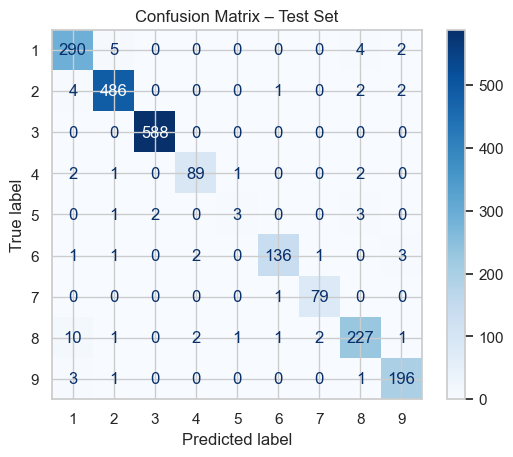

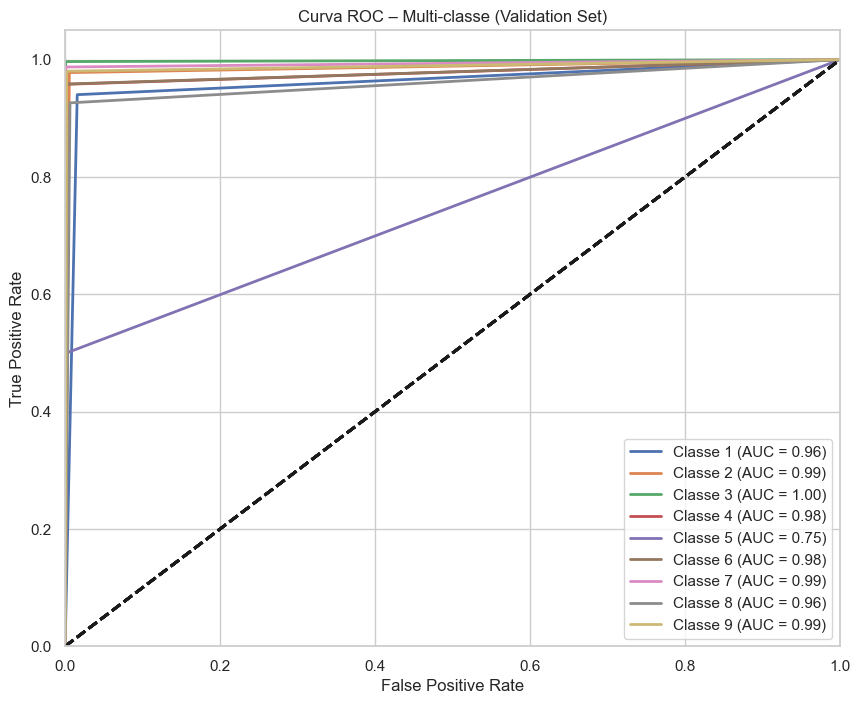

In [57]:
dc_tree = DecisionTreeClassifier(random_state=42)
dc_tree.fit(X_train, y_train)
y_test_pred = dc_tree.predict(X_test)
y_val_pred = dc_tree.predict(X_val)
drowData(y_test_pred,y_val_pred)
drowConfusionMatrix(y_test_pred) 
y_score = dc_tree.predict_proba(X_val)
drowROC(y_score)
result[dc_tree] = classification_report(y_test,y_test_pred)

<p> considerando che dai grafici sappiamo che abbiamo classi sbilanciate ci aspettavamo per la classe più numerosa i riusltati fossero ottimi mentre per la classe meno numerosa fossero i peggiori, percio adesso proviamo con la tecnica dello stratifiedKfold che mantiene le stesse proporzioni per ogni fold del dataset originale  </p>

In [58]:
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(dc_tree, X, y, cv=cv)
print(classification_report(y, y_pred, digits=3))
cls = 5
prec_5 = precision_score(y, y_pred, labels=[cls], average='macro', zero_division=0)
rec_5  = recall_score   (y, y_pred, labels=[cls], average='macro', zero_division=0)
f1_5   = f1_score       (y, y_pred, labels=[cls], average='macro', zero_division=0)
print(f"Classe {cls}: precision={prec_5:.3f}, recall={rec_5:.3f}, f1={f1_5:.3f}")
result[cv] = classification_report(y, y_pred, digits=3)


              precision    recall  f1-score   support

           1      0.955     0.938     0.946      1504
           2      0.984     0.987     0.985      2478
           3      0.997     0.998     0.998      2942
           4      0.975     0.977     0.976       474
           5      0.829     0.690     0.753        42
           6      0.965     0.968     0.967       721
           7      0.965     0.985     0.975       397
           8      0.938     0.945     0.942      1223
           9      0.972     0.974     0.973      1007

    accuracy                          0.974     10788
   macro avg      0.953     0.940     0.946     10788
weighted avg      0.974     0.974     0.974     10788

Classe 5: precision=0.829, recall=0.690, f1=0.753


<p> bilanciando le classi infatti adesso i risultati per le classi minoritarie sono migliorati ,adesso possiamo testare altri algoritmi con i dati 'sporchi' per vedere le differenze con gli alberi di decisione</p>
<center><h3 style = "background:#98c1d9 ;color:black;border:0;font-weight:bold">Random Forest con Grid Search</h3></center>

Migliori parametri trovati: {'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
              precision    recall  f1-score   support

           1       0.95      0.99      0.97       301
           2       1.00      0.99      0.99       495
           3       1.00      1.00      1.00       588
           4       0.95      0.99      0.97        95
           5       1.00      0.78      0.88         9
           6       0.99      0.97      0.98       144
           7       0.98      1.00      0.99        80
           8       0.99      0.95      0.97       245
           9       0.99      0.99      0.99       201

    accuracy                           0.99      2158
   macro avg       0.98      0.96      0.97      2158
weighted avg       0.99      0.99      0.99      2158



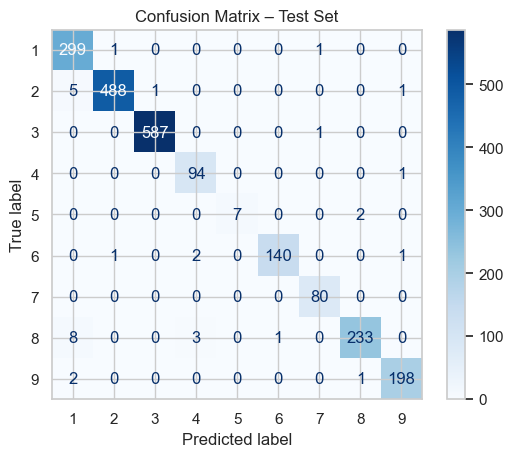

In [59]:
rf = RandomForestClassifier(random_state=42, class_weight="balanced")
param_grid = {
    'n_estimators': [100, 200],          
    'max_depth': [10, 30],          
    'min_samples_split': [10, 20],          
    'min_samples_leaf': [5, 10],           
    'max_features': ['sqrt', 'log2']         
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='f1_macro')  
grid_search.fit(X_train, y_train) 
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test) 
print("Migliori parametri trovati:", grid_search.best_params_)
print(classification_report(y_test, y_pred_rf))
drowConfusionMatrix(y_pred_rf)
result[rf] = classification_report(y_test, y_pred_rf)


<center><h3 style = "background:#98c1d9 ;color:black;border:0;font-weight:bold">KNN e SVC</h3></center>


 KNN
Validation set results
              precision    recall  f1-score   support

           1       0.83      0.83      0.83       301
           2       0.89      0.91      0.90       496
           3       1.00      0.98      0.99       589
           4       0.79      0.95      0.86        95
           5       0.00      0.00      0.00         8
           6       0.85      0.65      0.74       144
           7       0.82      0.91      0.86        79
           8       0.89      0.88      0.88       244
           9       0.83      0.90      0.86       202

    accuracy                           0.89      2158
   macro avg       0.77      0.78      0.77      2158
weighted avg       0.89      0.89      0.89      2158

Test set results
              precision    recall  f1-score   support

           1       0.84      0.80      0.82       301
           2       0.90      0.92      0.91       495
           3       1.00      0.99      1.00       588
           4       0.73      0.9

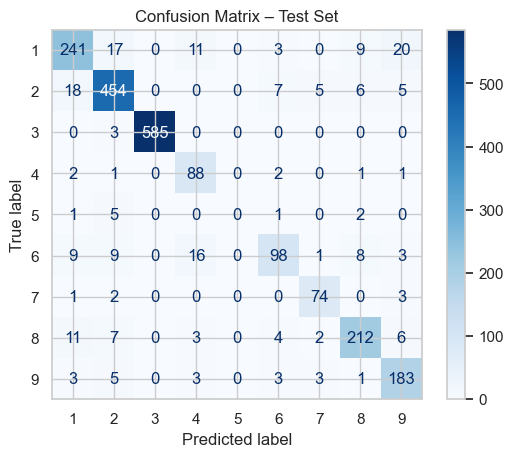


 SVC
Validation set results
              precision    recall  f1-score   support

           1       0.27      0.35      0.30       301
           2       0.55      0.50      0.53       496
           3       0.82      1.00      0.90       589
           4       0.00      0.00      0.00        95
           5       0.00      0.00      0.00         8
           6       0.00      0.00      0.00       144
           7       0.00      0.00      0.00        79
           8       0.29      0.71      0.41       244
           9       0.00      0.00      0.00       202

    accuracy                           0.52      2158
   macro avg       0.21      0.28      0.24      2158
weighted avg       0.42      0.52      0.45      2158

Test set results
              precision    recall  f1-score   support

           1       0.26      0.32      0.28       301
           2       0.53      0.45      0.49       495
           3       0.80      1.00      0.89       588
           4       0.00      0.0

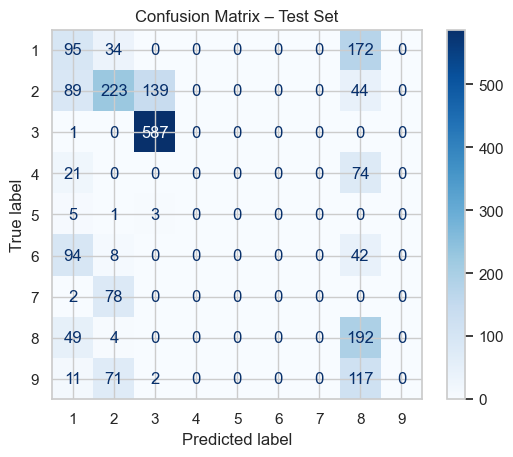

In [60]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=6),
    "SVC": SVC(),
}

for name in models.keys():
    model = models[name]
    print(f"\n {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_val_pred = model.predict(X_val)
    drowData(y_pred,y_val_pred)
    drowConfusionMatrix(y_pred)
    result[model] = classification_report(y_test, y_test_pred, zero_division=0)
    

<p> notiamo dai risultati ottenuti che il KNN non riesce a classificare la classe 5 e che SVC ha risultati non buoni, ci aspettavamo questi risultati perche entrambi lavorano con le distanza , e dall'esplorazione dei dati sappiamo che il data set originale ha valori continui e non discreti . Riproviamo i 2 algotmi andando a usare grid search con smote per bilanciare le classi e scaler per discretizzare i dati.</p>

In [61]:
pipeline = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])
param_grid = { 'knn__n_neighbors': list(range(1, 21))}
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',  
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)
print("Miglior k trovato:", grid.best_params_['knn__n_neighbors'])
print("F1 macro ottenuto:", grid.best_score_)
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))
result[pipeline] = classification_report(y_test, y_pred)

pipeline = Pipeline(steps=[
    ('scaler', MinMaxScaler()),               
    ('smote', SMOTE(random_state=42)),          
    ('svc', SVC())                              
])
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['rbf', 'linear'],
    'svc__gamma': ['scale', 'auto']
}
grid.fit(X_train, y_train)
print("Migliori parametri trovati:", grid.best_params_)
print("F1 macro CV:", grid.best_score_)
y_pred = grid.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
result[pipeline] = classification_report(y_test, y_pred)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Miglior k trovato: 1
F1 macro ottenuto: 0.9526646937209098
              precision    recall  f1-score   support

           1       0.95      0.98      0.96       301
           2       1.00      0.99      0.99       495
           3       1.00      1.00      1.00       588
           4       0.95      0.98      0.96        95
           5       0.75      0.67      0.71         9
           6       0.97      0.97      0.97       144
           7       0.99      1.00      0.99        80
           8       0.97      0.95      0.96       245
           9       0.98      0.98      0.98       201

    accuracy                           0.98      2158
   macro avg       0.95      0.95      0.95      2158
weighted avg       0.98      0.98      0.98      2158

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Migliori parametri trovati: {'knn__n_neighbors': 1}
F1 macro CV: 0.9526646937209098

Classification Report:
    


<center><h1 style = "background:red ;color:black;border:0;font-weight:bold">CONCLUSIONI</h1></center> 
 

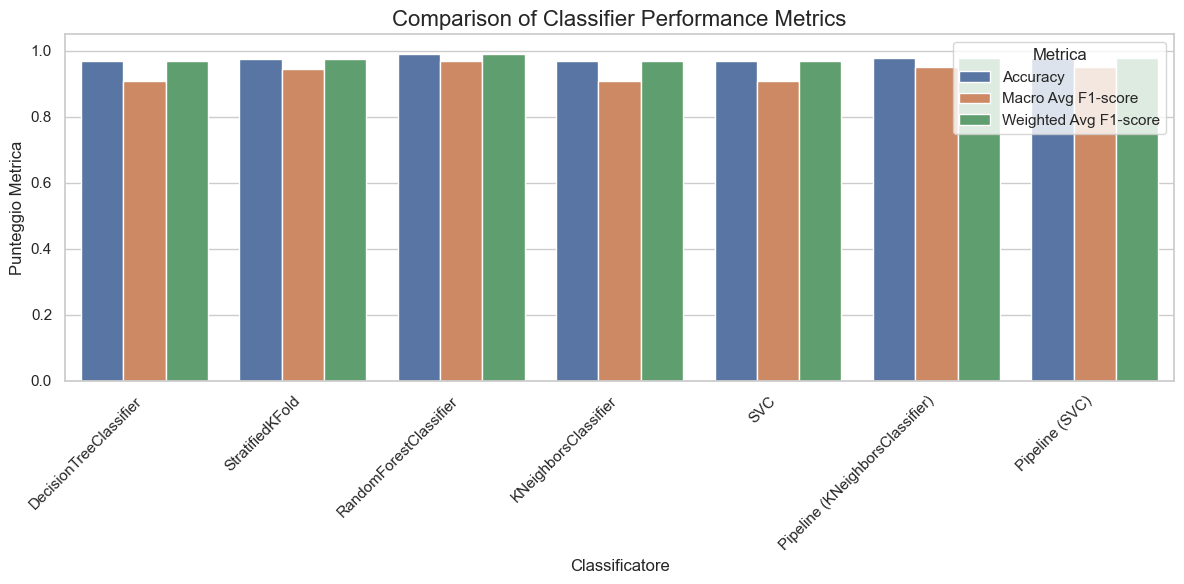

In [65]:
performance_data = []
for classifier_key, report_string in result.items():
    classifier_name = str(classifier_key)
    if isinstance(classifier_key, Pipeline):
         last_step_name = type(classifier_key.steps[-1][1]).__name__
         classifier_name = f"Pipeline ({last_step_name})"
    elif hasattr(classifier_key, '__class__'):
         classifier_name = type(classifier_key).__name__
    metrics = {'Classifier': classifier_name}
    report_lines = report_string.strip().split('\n')
    summary_lines = {}
    for line in reversed(report_lines):
        line = line.strip()
        if not line: continue
        if line.startswith('accuracy'): summary_lines['accuracy'] = line
        elif line.startswith('macro avg'): summary_lines['macro avg'] = line
        elif line.startswith('weighted avg'): summary_lines['weighted avg'] = line
        if len(summary_lines) == 3: break
    if 'accuracy' in summary_lines:
        try:
            float_values = [float(p) for p in summary_lines['accuracy'].split() if '.' in p]
            if float_values: metrics['Accuracy'] = float_values[-1]
        except ValueError: metrics['Accuracy'] = None
    if 'macro avg' in summary_lines:
        try:
            parts = summary_lines['macro avg'].split()
            metrics['Macro Avg Precision'] = float(parts[2])
            metrics['Macro Avg Recall'] = float(parts[3])
            metrics['Macro Avg F1-score'] = float(parts[4])
        except (IndexError, ValueError): pass
    if 'weighted avg' in summary_lines:
        try:
            parts = summary_lines['weighted avg'].split()
            metrics['Weighted Avg Precision'] = float(parts[2])
            metrics['Weighted Avg Recall'] = float(parts[3])
            metrics['Weighted Avg F1-score'] = float(parts[4])
        except (IndexError, ValueError): pass
    performance_data.append(metrics)
performance_df = pd.DataFrame(performance_data)
if not performance_df.empty:
    metrics_to_plot = [
        'Accuracy',
        'Macro Avg F1-score',
        'Weighted Avg F1-score'
    ]
    available_metrics_to_plot = [m for m in metrics_to_plot if m in performance_df.columns]
    if not available_metrics_to_plot:
         print("Nessuna metrica selezionata per il grafico trovata nel DataFrame.")
    else:
        df_melted = performance_df.melt(
            id_vars='Classifier',              
            value_vars=available_metrics_to_plot, 
            var_name='Metric Type',           
            value_name='Score'                 
        )
        sns.set_theme(style="whitegrid")
        plt.figure(figsize=(12, 6))
        barplot = sns.barplot(
            x='Classifier',     
            y='Score',          
            hue='Metric Type',  
            data=df_melted      
        )
        plt.title('Comparison of Classifier Performance Metrics', fontsize=16)
        plt.xlabel('Classificatore', fontsize=12)
        plt.ylabel('Punteggio Metrica', fontsize=12)
        plt.ylim(0, 1.05) 
        plt.xticks(rotation=45, ha='right') 
        plt.tight_layout() 
        plt.legend(title='Metrica')
        plt.show()
else:
    print("\nImpossibile creare il grafico: performance_df è vuoto.")

<i> in conclusione alla fine del progetto e dei test sugli algoritmi usati ,come si può vedere dal grafico dei risultati medi ottenuti ,possiamo dire che il classificatore che ha ottenuto i risultati migliori è il <b> RANDOM FOREST </b> ,ed era deducibile considerando che è stato usato con la cross validation </i>
